# Práctico 2 — Curación de datos e integración

**Mentoría M09 — El impacto de la IA en la fuerza laboral**

Dataset: [diplodatos-ai-impact-workforce](https://github.com/carolinapepe/diplodatos-ai-impact-workforce)

En el Práctico 1 exploramos el dataset y encontramos varias cosas para arreglar: variables de empleo que eran conteos absolutos, valores negativos que no tenían sentido económico y curtosis altísimas en algunas variables de retorno. En este práctico nos ocupamos de eso y dejamos el dataset listo para el Práctico 3.

El objetivo es juntar los tres archivos en una sola tabla, limpiarla y quedarnos con las variables que realmente vamos a usar.

---

## Índice

| Sección | Contenido |
|---|---|
| [1. Integración de los archivos](#1) | Cómo unimos las tres tablas y qué pasó con los registros sin match |
| [2. Valores faltantes](#2) | Qué falta, por qué falta y qué hicimos con eso |
| [3. Outliers](#3) | Cómo detectamos los valores raros y cuáles tratamos |
| [4. Variables categóricas](#4) | Cuáles codificamos y cuáles descartamos |
| [5. Selección de variables](#5) | Con qué variables nos quedamos para el P3 |
| [6. Conclusiones parciales](#6) | Cómo quedó el dataset |

Una decisión que traemos del P1: el análisis se hace **a nivel empresa**, promediando trimestres, porque las variables económicas concentraban entre 70% y 88% de su varianza dentro de cada empresa (§ 2.4 del P1). Esa agregación la dejamos para el final del práctico.

<a id="1"></a>

---

# 1. Integración de los archivos

> **Consigna**
> Integrá los tres archivos en una única estructura. Explicá qué columna usaste para unir cada tabla, qué pasa con los registros sin match, y describí brevemente el dataset resultante.

## 1.1 Librerías y carga de datos

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [4]:
# Clone the repository if it doesn't already exist
if not os.path.exists('Proyecto-mentoria-M09'):
    !git clone https://github.com/carolinapepe/diplodatos-ai-impact-workforce.git Proyecto-mentoria-M09

Cloning into 'Proyecto-mentoria-M09'...
remote: Enumerating objects: 25, done.
remote: Counting objects: 100% (25/25), done.
remote: Compressing objects: 100% (18/18), done.
remote: Total 25 (delta 4), reused 25 (delta 4), pack-reused 0 (from 0)
Receiving objects: 100% (25/25), 9.89 MiB | 11.94 MiB/s, done.
Resolving deltas: 100% (4/4), done.


In [9]:
# Leemos desde el repositorio local. Los datos vienen incluidos en el clon (data/raw/),
# asi que no hace falta descargar nada: en Colab basta con clonar el repo y pararse en notebooks/.
RAW = "Proyecto-mentoria-M09/data/raw/"

df1 = pd.read_csv(RAW + "ai_company_adoption.csv")   # encuestas: una fila por empresa y trimestre
df2 = pd.read_csv(RAW + "ai_industry_summary.csv")   # resumen por industria
df3 = pd.read_csv(RAW + "country_ai_index.csv")      # indicadores por pais

print(f"df1  {df1.shape[0]:>7,} filas x {df1.shape[1]:>2} columnas")
print(f"df2  {df2.shape[0]:>7,} filas x {df2.shape[1]:>2} columnas")
print(f"df3  {df3.shape[0]:>7,} filas x {df3.shape[1]:>2} columnas")

df1  150,025 filas x 43 columnas
df2        9 filas x  8 columnas
df3       30 filas x  8 columnas


## 1.2 Cómo se relacionan los tres archivos

Los tres archivos se relacionan así: `df1` tiene una fila por empresa y trimestre, y es la tabla principal. `df2` tiene una fila por industria y `df3` una fila por país, o sea que son tablas chicas de consulta. Lo que hacemos es pegarle a `df1` la información de las otras dos.

Las columnas que usamos para unir son `industry` (para `df2`) y `country` (para `df3`). Son claves foráneas: miles de encuestas de `df1` apuntan a la misma fila de industria o de país.

Ojo con no confundirlas con `company_id`, que agrupa filas dentro de `df1` (por eso hay 10.025 empresas en 150.025 filas) pero no conecta con los otros archivos.

**Por qué usamos `LEFT JOIN`**

Arrancamos siempre desde `df1` con `how="left"` para no perder ninguna fila y que cada fila siga representando una encuesta. Si usáramos `inner join` se irían las encuestas que tienen `industry` o `country` vacío, y esas filas tienen datos válidos en las otras 40 columnas. En resumen, sería: obtengo todo lo de A (df1), y de B (df2/df3) solamente lo que coincida.

Antes de mergear conviene chequear algunas cosas, porque si el join sale mal no tira error: devuelve un DataFrame con el tamaño equivocado y el problema se arrastra hasta el final.

In [14]:
# --- 1. Unicidad de la clave en cada tabla de dimension ---
# Si la clave estuviera repetida en df2 o df3, el merge multiplicaria filas de df1 en silencio.
print("Claves duplicadas en df2 (industry):", df2["industry"].duplicated().sum())
print("Claves duplicadas en df3 (country) :", df3["country"].duplicated().sum())

# --- 2. Cobertura: toda clave presente en df1 existe en la dimension? ---
ind_sin_match  = set(df1["industry"].dropna()) - set(df2["industry"])
pais_sin_match = set(df1["country"].dropna())  - set(df3["country"])
print("\nIndustrias de df1 que no existen en df2:", ind_sin_match or "ninguna")
print("Paises de df1 que no existen en df3    :", pais_sin_match or "ninguna")

# --- 3. Colision de nombres: columnas que aparecen en mas de una tabla ---
comunes_12 = (set(df1.columns) & set(df2.columns)) - {"industry"}
comunes_13 = (set(df1.columns) & set(df3.columns)) - {"country"}
print("\nColumnas repetidas entre df1 y df2 (ademas de la clave):", comunes_12 or "ninguna")
print("Columnas repetidas entre df1 y df3 (ademas de la clave):", comunes_13 or "ninguna")

# 'region' esta en df1 y en df3: verificamos que digan lo mismo antes de descartar una de las dos
chequeo_region = (
    df1[["country", "region"]].dropna().drop_duplicates()
       .merge(df3[["country", "region"]], on="country", suffixes=("_df1", "_df3"))
)
discrepancias = (chequeo_region["region_df1"] != chequeo_region["region_df3"]).sum()
print(f"\nPaises con region discrepante entre df1 y df3: {discrepancias} de {len(chequeo_region)}")

Claves duplicadas en df2 (industry): 0
Claves duplicadas en df3 (country) : 0

Industrias de df1 que no existen en df2: ninguna
Paises de df1 que no existen en df3    : ninguna

Columnas repetidas entre df1 y df2 (ademas de la clave): ninguna
Columnas repetidas entre df1 y df3 (ademas de la clave): {'region'}

Paises con region discrepante entre df1 y df3: 0 de 30


Las tres verificaciones dieron bien. Las claves no están repetidas ni en `df2` ni en `df3`, todas las industrias y países que aparecen en `df1` existen en las tablas chicas, y `region` —que está en los dos archivos— dice exactamente lo mismo en los 30 países. Como es información repetida, nos quedamos con la de `df1` y descartamos la de `df3`.

> **Un detalle del P1.** En la celda del mapa del P1 habíamos renombrado `USA → United States` y `UK → United Kingdom` en `df3` para que Plotly reconociera los países. Acá no lo repetimos, porque `df1` usa las abreviaturas y si lo aplicáramos antes del merge esos dos países se quedarían sin match. Fue un cambio que servía para el gráfico, no para unir las tablas.

## 1.3 Integración

In [15]:
# 'region' ya fue verificada como consistente: descartamos la copia de df3 para no duplicar la columna
df3_dim = df3.drop(columns="region")

df = (
    df1
    .merge(df2,     on="industry", how="left", validate="m:1", indicator="match_industry")
    .merge(df3_dim, on="country",  how="left", validate="m:1", indicator="match_country")
)

# Control de integridad: el merge no deberia perder ni duplicar ninguna fila
print(f"Filas antes del merge   : {len(df1):,}")
print(f"Filas despues del merge : {len(df):,}")
print(f"Columnas: {df1.shape[1]} -> {df.shape[1]}")
print(f"\nGranularidad intacta (sigue habiendo una fila por encuesta): {len(df) == len(df1)}")

Filas antes del merge   : 150,025
Filas despues del merge : 150,025
Columnas: 43 -> 58

Granularidad intacta (sigue habiendo una fila por encuesta): True


Puede parecer al pedo contar las filas después de un merge, pero es justo lo que se puede romper sin que te des cuenta. Un join puede cambiar el tamaño del dataset de dos formas:

- **Perder filas**, si usás `how="inner"` y hay claves sin match. Acá se habrían ido 2.253 encuestas.
- **Duplicar filas**, si la tabla de la derecha tiene la clave repetida.

La segunda es la jodida, porque no salta ningún error y el DataFrame se ve normal. En la celda de abajo simulamos ese caso para ver qué pasaría.

In [16]:
# --- Simulacion: que pasaria si df2 tuviera una industria repetida ---
# (no modifica nada, es solo para dimensionar el riesgo que previene validate="m:1")
df2_roto = pd.concat([df2, df2[df2["industry"] == "Technology"]], ignore_index=True)

merge_ok   = df1.merge(df2,      on="industry", how="left")
merge_roto = df1.merge(df2_roto, on="industry", how="left")

print(f"Encuestas de Technology en df1 : {(df1['industry'] == 'Technology').sum():,}")
print(f"  ... en el merge correcto     : {(merge_ok['industry']   == 'Technology').sum():,}")
print(f"  ... en el merge duplicado    : {(merge_roto['industry'] == 'Technology').sum():,}  <- aparecen dos veces\n")
print(f"Total de filas, merge correcto : {len(merge_ok):,}")
print(f"Total de filas, merge duplicado: {len(merge_roto):,}\n")

print("Efecto sobre cualquier estadistico posterior:")
print(f"  media de jobs_displaced, merge correcto : {merge_ok['jobs_displaced'].mean():.2f}")
print(f"  media de jobs_displaced, merge duplicado: {merge_roto['jobs_displaced'].mean():.2f}")

# Con la validacion, pandas corta en vez de devolver un dataset silenciosamente mal ponderado
try:
    df1.merge(df2_roto, on="industry", how="left", validate="m:1")
except Exception as e:
    print(f"\nCon validate='m:1' el merge falla: {type(e).__name__}")
    print(f"  {str(e).splitlines()[0]}")

Encuestas de Technology en df1 : 20,805
  ... en el merge correcto     : 20,805
  ... en el merge duplicado    : 41,610  <- aparecen dos veces

Total de filas, merge correcto : 150,025
Total de filas, merge duplicado: 170,830

Efecto sobre cualquier estadistico posterior:
  media de jobs_displaced, merge correcto : 111.37
  media de jobs_displaced, merge duplicado: 114.14

Con validate='m:1' el merge falla: MergeError
  Merge keys are not unique in right dataset; not a many-to-one merge


Con la industria duplicada, las 20.805 encuestas de Technology pasan a contarse dos veces y el dataset queda con 170.830 filas. El promedio de `jobs_displaced` se mueve de 111,37 a 114,14, o sea que Technology pesa el doble de lo que le corresponde en cualquier promedio o correlación que calculemos después.

Lo peor es que nada te avisa: las columnas están bien y `head()` se ve normal. Con `validate="m:1"` pandas tira un `MergeError` en el momento, que es mucho mejor que enterarte al final.

## 1.4 Registros sin match

In [17]:
for col_ind, clave in [("match_industry", "industry"), ("match_country", "country")]:
    sin_match  = (df[col_ind] == "left_only").sum()
    clave_nula = df1[clave].isna().sum()
    print(f"{clave:9s} -> filas sin match: {sin_match:>6,} ({sin_match/len(df)*100:.2f}%)"
          f" | filas con la clave nula en df1: {clave_nula:>6,}"
          f" | coinciden? {sin_match == clave_nula}")

# Las filas sin match conservan sus datos propios: solo quedan vacias las columnas heredadas
cols_df2 = [c for c in df2.columns if c != "industry"]
ejemplo = df.loc[df["match_industry"] == "left_only",
                 ["company_id", "industry", "ai_adoption_rate"] + cols_df2[:3]]
print(f"\nEjemplo de filas sin match en industry ({len(ejemplo):,} en total):")
ejemplo.head(3)

industry  -> filas sin match:  2,253 (1.50%) | filas con la clave nula en df1:  2,253 | coinciden? True
country   -> filas sin match:      1 (0.00%) | filas con la clave nula en df1:      1 | coinciden? True

Ejemplo de filas sin match en industry (2,253 en total):


,company_id,industry,ai_adoption_rate,avg_ai_adoption_rate,avg_productivity_change_percent,avg_ai_maturity_score
7,COMP-00001,NaN,57.42,NaN,NaN,NaN
96,COMP-00007,NaN,6.11,NaN,NaN,NaN
200,COMP-00014,NaN,55.21,NaN,NaN,NaN


No perdimos ninguna fila: quedaron las 150.025 encuestas. Y las únicas filas sin match son justo las que tenían la clave vacía en `df1` (2.253 sin `industry` y 1 sin `country`). No hay ningún caso de una industria o país que exista en `df1` pero no en las tablas chicas, así que el problema no es del merge sino que el dato ya venía faltando.

Esas filas mantienen sus 43 columnas originales y quedan con las columnas nuevas en `NaN`. Qué hacer con ellas lo vemos en la sección 2, que es donde analizamos los faltantes. Descartarlas acá sería adelantarnos.

In [18]:
# Las columnas de auditoria ya cumplieron su funcion
df = df.drop(columns=["match_industry", "match_country"])

## 1.5 ¿Qué información aporta cada tabla?

Integrar no es solo pegar columnas, también hay que mirar qué estamos pegando. `df2` trae promedios por industria, pero en ningún lado dice si son un relevamiento aparte o simplemente una cuenta hecha sobre `df1`.

La diferencia importa. Si alguien te pasa una planilla con las notas de todos los alumnos de un colegio, y después otra con el promedio por curso, la segunda no te está dando información nueva: es una cuenta que podías hacer vos con la primera.

Para saber en cuál de los dos casos estamos, comparamos cada columna `avg_*` de `df2` contra el promedio por industria calculado desde `df1`.

In [19]:
# Cada columna avg_* de df2 tiene su contraparte a nivel encuesta en df1
pares = {
    "avg_ai_adoption_rate":            "ai_adoption_rate",
    "avg_productivity_change_percent": "productivity_change_percent",
    "avg_ai_maturity_score":           "ai_maturity_score",
    "avg_ai_failure_rate":             "ai_failure_rate",
    "avg_jobs_displaced":              "jobs_displaced",
    "avg_jobs_created":                "jobs_created",
    "avg_customer_satisfaction":       "customer_satisfaction",
}

promedios_calculados = df1.groupby("industry")[list(pares.values())].mean()
df2_idx = df2.set_index("industry")

# Dos medidas complementarias:
#   - dif_abs_media: cuanto se separan los numeros, en las unidades de la variable
#   - correlacion  : si ordenan a las industrias de la misma manera
# Hacen falta las dos: si una tabla estuviera en otra escala (todo x10) la correlacion
# seguiria dando 1 y los numeros serian completamente distintos.
comparacion = pd.DataFrame([
    {
        "columna_df2":   col_df2,
        "equivale_a":    f"mean({col_df1}) por industria",
        "dif_abs_media": (df2_idx[col_df2]
                          - promedios_calculados[col_df1].reindex(df2_idx.index)).abs().mean(),
        "correlacion":   np.corrcoef(df2_idx[col_df2],
                                     promedios_calculados[col_df1].reindex(df2_idx.index))[0, 1],
    }
    for col_df2, col_df1 in pares.items()
]).round(3)

comparacion

,columna_df2,equivale_a,dif_abs_media,correlacion
0,avg_ai_adoption_rate,mean(ai_adoption_rate) por industria,0.035,1.000
1,avg_productivity_change_percent,mean(productivity_change_percent) por industria,0.045,1.000
2,avg_ai_maturity_score,mean(ai_maturity_score) por industria,0.002,0.995
3,avg_ai_failure_rate,mean(ai_failure_rate) por industria,0.005,1.000
4,avg_jobs_displaced,mean(jobs_displaced) por industria,0.201,1.000
5,avg_jobs_created,mean(jobs_created) por industria,0.162,1.000
6,avg_customer_satisfaction,mean(customer_satisfaction) por industria,0.003,0.999


In [20]:
# Detalle de una de las columnas, para ver los numeros uno al lado del otro
detalle = pd.DataFrame({
    "df2 dice":         df2_idx["avg_ai_adoption_rate"],
    "calculado de df1": promedios_calculados["ai_adoption_rate"],
})
detalle["diferencia"] = (detalle["df2 dice"] - detalle["calculado de df1"]).abs()
print("avg_ai_adoption_rate: df2 vs. el promedio calculado desde df1")
print(detalle.round(3).to_string())

# Cuantos valores distintos aporta realmente la columna una vez pegada a las 150.025 filas
print(f"\nValores distintos de 'industry'             en el dataset: {df['industry'].nunique()}")
print(f"Valores distintos de 'avg_ai_adoption_rate' en el dataset: {df['avg_ai_adoption_rate'].nunique()}")
print(f"Encuestas por industria (promedio): {df1['industry'].value_counts().mean():,.0f}")
print(f"Nulos en ai_adoption_rate: {df1['ai_adoption_rate'].isna().sum():,} "
      f"({df1['ai_adoption_rate'].isna().mean() * 100:.2f}%)")

avg_ai_adoption_rate: df2 vs. el promedio calculado desde df1
               df2 dice  calculado de df1  diferencia
industry                                             
Agriculture       35.25            35.224       0.026
Consulting        34.52            34.567       0.047
Education         35.23            35.326       0.096
Finance           38.35            38.329       0.021
Healthcare        34.57            34.568       0.002
Logistics         35.26            35.303       0.043
Manufacturing     34.73            34.756       0.026
Retail            34.70            34.727       0.027
Technology        42.47            42.500       0.030

Valores distintos de 'industry'             en el dataset: 9
Valores distintos de 'avg_ai_adoption_rate' en el dataset: 9
Encuestas por industria (promedio): 16,419
Nulos en ai_adoption_rate: 2,249 (1.50%)


`df2` no es información externa: es `df1` promediado por industria. Las siete columnas dan prácticamente los mismos números (las diferencias están en el tercer decimal) y las correlaciones van de 0,995 a 1,000.

Miramos las dos medidas juntas porque dicen cosas distintas: la diferencia media nos confirma que son los mismos números y la correlación que además ordenan las industrias igual. Con la correlación sola no alcanzaría, porque si `df2` tuviera todos los valores multiplicados por 10 seguiría dando 1,000.

La diferencia chiquita que queda se explica sola: `ai_adoption_rate` tiene 2.249 valores vacíos, así que si la fuente los contó distinto que nosotros el promedio queda apenas corrido.

**Qué significa esto para el modelado**

Que estas columnas no aportan nada nuevo. Una vez pegada a las 150.025 filas, `avg_ai_adoption_rate` toma solo 9 valores distintos: los mismos 9 que tiene `industry`. Todas las empresas de Technology reciben 42,47 y todas las de Finance, 38,35. O sea que la columna dice "a qué industria pertenece la empresa", pero con números en vez de palabras, y eso ya lo tenemos en `industry`.

Es como tener una columna "país" y otra "código de país": dos columnas para un solo dato. Si metemos las dos, el modelo reparte el mérito entre columnas gemelas y ninguna termina pareciendo importante.

Hay un segundo problema, más chico. Los promedios se calcularon con todo el dataset, así que ya incluyen a las empresas que después van a quedar del lado de la validación. Cuando dividamos en entrenamiento y prueba, esas columnas van a tener adentro información del test: es data leakage. Igual acá es poca cosa, porque cada encuesta aporta 1 parte entre ~16.400 al promedio de su industria.

Con `df3` pasa lo contrario. PBI per cápita, penetración de internet, madurez digital, patentes, investigadores y política regulatoria son datos que no se pueden sacar de `df1` de ninguna manera, así que ahí sí hay información nueva sobre el contexto en el que opera cada empresa.

Igual dejamos las columnas de `df2` en el dataset porque la consigna pide integrar los tres archivos. La decisión de si entran al modelado la tomamos en la § 5.

## 1.6 El dataset resultante

In [21]:
cols_df3 = [c for c in df3_dim.columns if c != "country"]

print(f"Dataset integrado: {df.shape[0]:,} filas x {df.shape[1]} columnas")
print(f"Granularidad     : una fila por empresa y trimestre "
      f"({df['company_id'].nunique():,} empresas, "
      f"{df.groupby('company_id').size().max()} trimestres como maximo)\n")

print(f"Columnas propias de df1 ({len(df1.columns)}): la encuesta a nivel empresa x trimestre")
print(f"Columnas de df2         ({len(cols_df2)}): {cols_df2}")
print(f"Columnas de df3         ({len(cols_df3)}): {cols_df3}\n")

n_num = df.select_dtypes(include=np.number).shape[1]
print(f"Tipos: {n_num} numericas | {df.shape[1] - n_num} categoricas")

Dataset integrado: 150,025 filas x 56 columnas
Granularidad     : una fila por empresa y trimestre (10,025 empresas, 16 trimestres como maximo)

Columnas propias de df1 (43): la encuesta a nivel empresa x trimestre
Columnas de df2         (7): ['avg_ai_adoption_rate', 'avg_productivity_change_percent', 'avg_ai_maturity_score', 'avg_ai_failure_rate', 'avg_jobs_displaced', 'avg_jobs_created', 'avg_customer_satisfaction']
Columnas de df3         (6): ['gdp_per_capita', 'internet_penetration', 'digital_maturity_index', 'country_ai_policy', 'ai_patent_filings_2024', 'ai_researchers_per_million']

Tipos: 41 numericas | 15 categoricas


In [22]:
df.head(3)

,response_id,company_id,survey_year,quarter,country,region,industry,company_size,num_employees,annual_revenue_usd_millions,...,avg_ai_failure_rate,avg_jobs_displaced,avg_jobs_created,avg_customer_satisfaction,gdp_per_capita,internet_penetration,digital_maturity_index,country_ai_policy,ai_patent_filings_2024,ai_researchers_per_million
0,1,COMP-00001,2023.0,Q1,Italy,Europe,Education,Startup,57.0,48.31,...,26.13,111.25,122.58,5.37,39436.63,86.01,75.65,Moderate,2234.0,296.83
1,2,COMP-00001,2023.0,Q2,Italy,Europe,Education,Startup,57.0,48.31,...,26.13,111.25,122.58,5.37,39436.63,86.01,75.65,Moderate,2234.0,296.83
2,3,COMP-00001,2023.0,Q3,Italy,Europe,Education,NaN,57.0,48.31,...,26.13,111.25,122.58,5.37,39436.63,86.01,75.65,Moderate,2234.0,296.83


El dataset integrado quedó en **150.025 filas y 56 columnas**, con la misma granularidad que `df1`: una fila por empresa y trimestre, 10.025 empresas y hasta 16 trimestres cada una. A las 43 columnas originales le sumamos 7 promedios por industria y 6 indicadores por país (la `region` de `df3` la descartamos porque estaba repetida).

Repaso de lo que decidimos:

| Decisión | Por qué |
|---|---|
| `LEFT JOIN` desde `df1` | Para que cada fila siga siendo una encuesta y no perder ninguna |
| Unir por `industry` y `country` | Son las claves que conectan las tablas, y no están repetidas |
| Usar `validate="m:1"` | Para que pandas avise si el merge duplica filas |
| Descartar `region` de `df3` | Estaba repetida y decía lo mismo que la de `df1` |
| No renombrar `USA`/`UK` | Rompería el match de esos dos países |
| Dejar las filas sin match | Sus otras columnas están bien; las tratamos en la § 2 |

Queda anotado para la § 5 que las columnas de `df2` son una cuenta hecha sobre `df1`.

**Una aclaración sobre el orden.** Integramos sobre el panel completo de 150.025 filas y no sobre el dataset ya agregado por empresa. El P1 decidió trabajar a nivel empresa, pero esa agregación la dejamos para el final: si promediáramos ahora, los valores raros que vamos a buscar en la § 3 quedarían escondidos adentro del promedio de cada empresa y no los podríamos detectar.

<a id="2"></a>

---

# 2. Valores faltantes

> **Consigna**
> Identificá qué variables tienen valores faltantes y en qué proporción. Para cada una, evaluá distintas estrategias posibles (imputación, eliminación de filas, eliminación de la variable) y justificá la que elegiste. Implementala.

## 2.1 Qué falta y cuánto

In [23]:
faltantes = df.isna().sum()
faltantes = faltantes[faltantes > 0].sort_values(ascending=False)

# Las columnas heredadas de df2/df3 no tienen un problema propio: quedaron vacias en las
# filas cuya clave (industry / country) venia nula, tal como se vio en la seccion 1.4.
heredadas = [c for c in faltantes.index if c in cols_df2 + cols_df3]
propias   = [c for c in faltantes.index if c not in heredadas]

tabla_faltantes = pd.DataFrame({
    "nulos":  faltantes,
    "%":      (faltantes / len(df) * 100).round(3),
    "tipo":   df.dtypes[faltantes.index].astype(str),
    "origen": ["heredada del merge" if c in heredadas else "propia de df1" for c in faltantes.index],
})

print(f"Variables con faltantes: {len(faltantes)} de {df.shape[1]}")
print(f"  propias de df1     : {len(propias)}")
print(f"  heredadas del merge: {len(heredadas)}")
print(f"\nFilas sin ningun faltante: {df.notna().all(axis=1).sum():,} de {len(df):,} "
      f"({df.notna().all(axis=1).mean() * 100:.1f}%)")
tabla_faltantes

Variables con faltantes: 40 de 56
  propias de df1     : 27
  heredadas del merge: 13

Filas sin ningun faltante: 123,265 de 150,025 (82.2%)


,nulos,%,tipo,origen
industry,2253,1.502,object,propia de df1
avg_ai_adoption_rate,2253,1.502,float64,heredada del merge
avg_ai_maturity_score,2253,1.502,float64,heredada del merge
avg_ai_failure_rate,2253,1.502,float64,heredada del merge
avg_jobs_displaced,2253,1.502,float64,heredada del merge
avg_jobs_created,2253,1.502,float64,heredada del merge
avg_customer_satisfaction,2253,1.502,float64,heredada del merge
avg_productivity_change_percent,2253,1.502,float64,heredada del merge
customer_satisfaction,2252,1.501,float64,propia de df1
data_privacy_level,2252,1.501,object,propia de df1


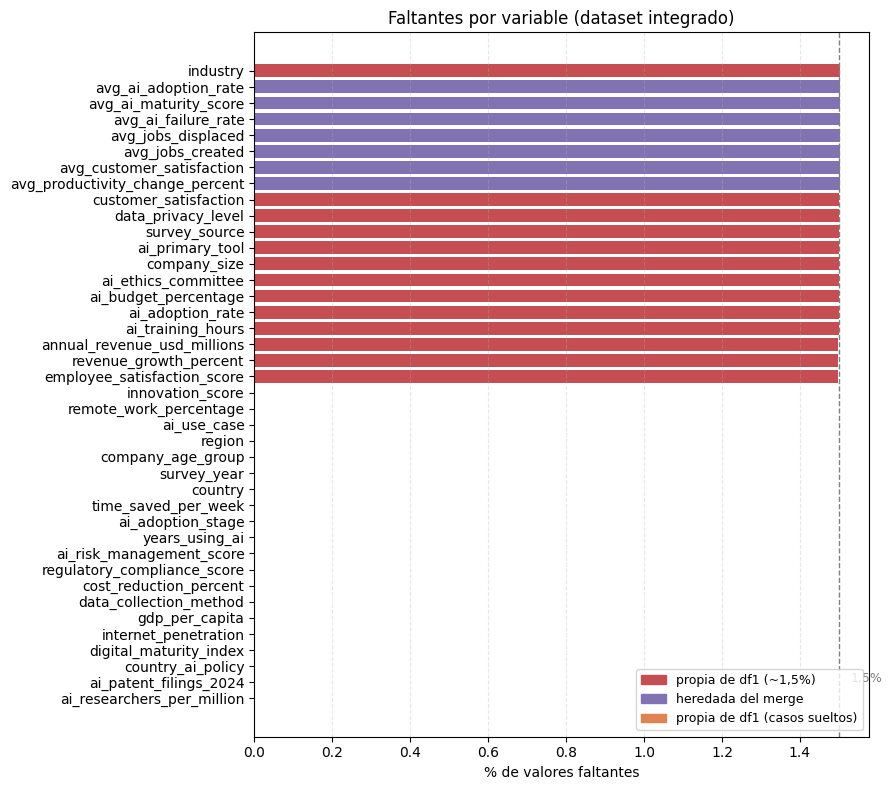

In [24]:
# El grafico separa los dos grupos de magnitud que se ven en la tabla
fig, ax = plt.subplots(figsize=(9, 8))
colores = ["#8172b3" if c in heredadas else ("#c44e52" if v > 1 else "#dd8452")
           for c, v in zip(tabla_faltantes.index, tabla_faltantes["%"])]
ax.barh(tabla_faltantes.index[::-1], tabla_faltantes["%"][::-1], color=colores[::-1])
ax.set_xlabel("% de valores faltantes")
ax.set_title("Faltantes por variable (dataset integrado)")
ax.axvline(1.5, ls="--", c="gray", lw=1)
ax.text(1.53, 1, "1,5%", color="gray", fontsize=9)
ax.grid(axis="x", alpha=0.3, ls="--")
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in ["#c44e52", "#8172b3", "#dd8452"]]
ax.legend(handles, ["propia de df1 (~1,5%)", "heredada del merge", "propia de df1 (casos sueltos)"],
          loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

De las 40 variables con faltantes, 13 en realidad no tienen un problema propio: son las columnas que trajimos con el merge y que quedaron vacías en las filas donde la clave venía nula (§ 1.4). Las 7 de `df2` copian los 2.253 faltantes de `industry` y las 6 de `df3`, el único faltante de `country`. Se van a arreglar solas cuando recuperemos esas columnas.

Las otras 27 son de `df1` y se dividen en dos grupos bastante distintos:

- **13 variables con ~1,5% cada una** (entre 2.247 y 2.253 nulos). Que sea tan parejo llama la atención: parece que vaciaron a propósito el 1,5% de los valores, variable por variable.
- **14 variables con 1 a 3 nulos**. Tan poquitos sobre 150.025 filas no parece un problema de la variable, sino unas pocas filas rotas que arrastran nulos en varias columnas a la vez.

Antes de decidir nada vale la pena mirar de dónde salen esas pocas filas.

## 2.2 De dónde salen los faltantes sueltos

In [25]:
# Aislamos las filas responsables de los faltantes "sueltos" (las variables con 1-3 nulos)
pocos_nulos = tabla_faltantes.index[tabla_faltantes["nulos"] <= 3]
filas_raras = df.index[df[pocos_nulos].isna().any(axis=1)]

print(f"Variables con 3 o menos nulos: {len(pocos_nulos)}")
print(f"Filas involucradas: {len(filas_raras)}\n")
df.loc[filas_raras, ["response_id", "company_id", "survey_year", "quarter", "country", "industry"]].head(8)

Variables con 3 o menos nulos: 20
Filas involucradas: 15



,response_id,company_id,survey_year,quarter,country,industry
150000,160001,COMP-FAKE-001,2026.0,Q3,Sweden,Finance
150001,160002,COMP-FAKE-002,2025.0,Q4,UK,Consulting
150003,160004,COMP-FAKE-004,2024.0,Q3,Germany,Healthcare
150004,160005,COMP-FAKE-005,2023.0,Q4,Spain,Healthcare
150006,160007,COMP-FAKE-007,2023.0,Q3,Sweden,Retail
150007,160008,COMP-FAKE-008,2025.0,Q4,South Korea,Technology
150008,160009,COMP-FAKE-009,2024.0,Q1,Poland,Finance
150009,160010,COMP-FAKE-010,2024.0,Q2,Canada,Logistics


In [26]:
# El company_id de esas filas es explicito. Buscamos el patron en todo el dataset.
es_fake = df["company_id"].str.contains("FAKE", na=False)

print(f"Filas con 'FAKE' en el company_id: {es_fake.sum()}")
print(f"company_id: {sorted(df.loc[es_fake, 'company_id'].unique())[:3]} ... "
      f"{sorted(df.loc[es_fake, 'company_id'].unique())[-1]}\n")

print(f"response_id de las filas FAKE    : {df.loc[es_fake, 'response_id'].min()} a {df.loc[es_fake, 'response_id'].max()}")
print(f"response_id maximo del resto     : {df.loc[~es_fake, 'response_id'].max()}")
print(f"Trimestres observados por empresa: {df[es_fake].groupby('company_id').size().unique()} "
      f"(el resto de las empresas tiene entre {df[~es_fake].groupby('company_id').size().min()} y "
      f"{df[~es_fake].groupby('company_id').size().max()})")
print(f"\nNulos promedio por fila: FAKE = {df[es_fake].isna().sum(axis=1).mean():.2f}  |  "
      f"resto = {df[~es_fake].isna().sum(axis=1).mean():.2f}")

Filas con 'FAKE' en el company_id: 25
company_id: ['COMP-FAKE-001', 'COMP-FAKE-002', 'COMP-FAKE-003'] ... COMP-FAKE-025

response_id de las filas FAKE    : 160001 a 160025
response_id maximo del resto     : 160000
Trimestres observados por empresa: [1] (el resto de las empresas tiene entre 10 y 16)

Nulos promedio por fila: FAKE = 2.44  |  resto = 0.30


Los faltantes sueltos no están repartidos por todo el dataset: se concentran en 25 filas que se llaman `COMP-FAKE-001` a `COMP-FAKE-025`. Hay cuatro cosas que confirman que son registros de prueba y no empresas reales:

1. El `company_id` lo dice directamente.
2. Sus `response_id` van de 160001 a 160025, fuera del rango del resto del archivo, que termina en 160000.
3. Aparecen una sola vez cada una, mientras que las demás empresas tienen entre 10 y 16 trimestres.
4. Tienen ocho veces más nulos por fila que el resto (2,44 contra 0,30).

Las opciones son: imputarles los valores faltantes (o sea inventar datos para completar registros que ya son falsos), dejarlas como están (y meter 25 "empresas" con un solo trimestre en todo el análisis) o eliminarlas.

Las eliminamos, justificando que son el 0,017% del dataset y el propio dato dice que son de falsas o de prueba.

In [27]:
df = df[~es_fake].copy()

print(f"Filas: {len(df):,}   |   Empresas: {df['company_id'].nunique():,}")
restantes = df.isna().sum()
print(f"\nVariables con faltantes: {len(restantes[restantes > 0])} (antes eran {len(faltantes)})")
print(f"Variables que quedaron completas: "
      f"{sorted(set(faltantes.index) - set(restantes[restantes > 0].index))}")

Filas: 150,000   |   Empresas: 10,000

Variables con faltantes: 20 (antes eran 40)
Variables que quedaron completas: ['ai_adoption_stage', 'ai_patent_filings_2024', 'ai_researchers_per_million', 'ai_risk_management_score', 'ai_use_case', 'company_age_group', 'cost_reduction_percent', 'country', 'country_ai_policy', 'data_collection_method', 'digital_maturity_index', 'gdp_per_capita', 'innovation_score', 'internet_penetration', 'region', 'regulatory_compliance_score', 'remote_work_percentage', 'survey_year', 'time_saved_per_week', 'years_using_ai']


Sacando esas 25 filas el dataset quedó en **150.000 filas y 10.000 empresas**. Además, 20 de las 40 variables con faltantes quedaron completas, entre ellas `country`, `region` y todas las que venían de `df3`.

Quedan 20 variables con faltantes: las 13 de `df1` con ~1,5% y las 7 de `df2` que dependen de `industry`. Las primeras son otro tema y las miramos aparte.

## 2.3 ¿Por qué faltan?

Antes de decidir cómo tratar un faltante conviene preguntarse por qué falta, porque de eso depende si taparlo mete sesgo o no.

En general se distinguen tres casos: que falte completamente al azar (MCAR), que la probabilidad de faltar dependa de otras variables que sí tenemos (MAR), o que dependa del valor que falta (MNAR, el peor de los tres, porque ahí cualquier imputación sesga).

El tercero no se puede descartar mirando los datos, pero sí podemos buscar señales del segundo: si los faltantes fueran parejos en todos los grupos y no se juntaran en las mismas filas, estaríamos más cerca del caso simple.

In [28]:
# El analisis del mecanismo se hace solo sobre las columnas propias de df1: los faltantes de
# las heredadas son una consecuencia mecanica del merge, no un fenomeno a explicar.
restantes = df.isna().sum()
var_15 = [c for c in restantes[restantes > 0].index if c not in cols_df2 + cols_df3]
print(f"Variables analizadas: {len(var_15)}\n")

# --- Prueba 1: la tasa de faltantes cambia segun caracteristicas observables? ---
print("Tasa de faltantes de ai_adoption_rate segun distintos cortes del dataset:\n")
for grupo in ["region", "company_size", "survey_year", "quarter", "data_collection_method"]:
    tasa = df.groupby(grupo, dropna=True)["ai_adoption_rate"].apply(lambda s: s.isna().mean() * 100)
    print(f"  por {grupo:23s} min={tasa.min():.2f}%  max={tasa.max():.2f}%  "
          f"amplitud={tasa.max() - tasa.min():.2f} pp")

# --- Prueba 2: los faltantes se concentran en las mismas filas? ---
M = df[var_15].isna()
observado = int((M.sum(axis=1) >= 2).sum())
p = M.mean().mean()
esperado = len(df) * (len(var_15) * (len(var_15) - 1) / 2) * p**2   # aprox. bajo independencia

print(f"\nFilas con 2 o mas faltantes simultaneos (sobre las {len(var_15)} variables):")
print(f"  observado : {observado:,}")
print(f"  esperado si cada variable faltara de forma independiente: {esperado:,.0f}")

Variables analizadas: 13

Tasa de faltantes de ai_adoption_rate segun distintos cortes del dataset:

  por region                  min=1.42%  max=1.64%  amplitud=0.22 pp
  por company_size            min=1.47%  max=1.54%  amplitud=0.07 pp
  por survey_year             min=1.37%  max=1.59%  amplitud=0.21 pp
  por quarter                 min=1.42%  max=1.57%  amplitud=0.15 pp
  por data_collection_method  min=1.44%  max=1.58%  amplitud=0.14 pp

Filas con 2 o mas faltantes simultaneos (sobre las 13 variables):
  observado : 2,375
  esperado si cada variable faltara de forma independiente: 2,630


Las dos pruebas dicen lo mismo.

La tasa de faltantes es casi igual en todos los cortes: entre regiones va de 1,42% a 1,64%, entre tamaños de empresa de 1,47% a 1,54%, y algo parecido por año, trimestre y método de recolección. Diferencias de 0,07 a 0,22 puntos porcentuales sobre 150.000 filas son ruido, no un patrón.

Y los faltantes tampoco se acumulan horizontalmente: las filas con dos o más faltantes al mismo tiempo son más o menos las que esperaríamos bajo independencia. No hay un grupo de encuestas mal completadas que arrastre varias columnas.

Conviene aclarar el límite: no podemos descartar que falten por su propio valor, porque para eso habría que conocer justamente los datos que faltan. Lo que sí podemos decir es que no aparece ninguna señal de que dependan de lo que sí observamos. Así que la decisión pasa por otro lado: **cuánta información conserva cada estrategia**.

## 2.4 Aprovechar que cada empresa aparece varias veces

Hay algo que todavía no aprovechamos: cada empresa aparece hasta 16 veces. Eso permite algo que en un dataset de una fila por caso sería imposible, que es buscar el dato faltante en los otros trimestres de la misma empresa.

La cuestión es que no todas las variables sirven para eso. Algunas describen cosas que no cambian (la industria de una empresa es la misma en 2023 y en 2026) y otras se miden en cada trimestre y cambian por definición.

Para las primeras, un faltante no es un dato perdido: es un dato que está escrito en otra fila. Veamos cuáles son cuáles.

In [29]:
diagnostico = []
for c in var_15:
    valores_por_empresa = df.groupby("company_id")[c].nunique(dropna=True)
    nulos = df[c].isna()
    tiene_en_otro_trim = df.groupby("company_id")[c].transform(lambda s: s.notna().any())
    diagnostico.append({
        "variable": c,
        "nulos": int(nulos.sum()),
        "max_valores_por_empresa": int(valores_por_empresa.max()),
        "constante_por_empresa": "SI" if valores_por_empresa.max() <= 1 else "no",
        "recuperables_del_panel": int((nulos & tiene_en_otro_trim).sum()),
        "empresas_sin_ningun_valor": int((~df.groupby("company_id")[c].apply(lambda s: s.notna().any())).sum()),
    })

pd.DataFrame(diagnostico).sort_values("max_valores_por_empresa")

,variable,nulos,max_valores_por_empresa,constante_por_empresa,recuperables_del_panel,empresas_sin_ningun_valor
0,industry,2250,1,SI,2250,0
1,company_size,2250,1,SI,2250,0
8,ai_ethics_committee,2250,2,no,2250,0
2,annual_revenue_usd_millions,2247,3,no,2247,0
7,data_privacy_level,2250,3,no,2250,0
12,survey_source,2250,4,no,2250,0
4,ai_primary_tool,2250,6,no,2250,0
3,ai_adoption_rate,2248,16,no,2248,0
6,ai_budget_percentage,2250,16,no,2250,0
5,ai_training_hours,2248,16,no,2248,0


La tabla divide las 13 variables en dos grupos.

Por un lado están `industry` y `company_size`, que toman **un solo valor por empresa** en sus 16 trimestres. Sus 2.250 faltantes son 100% recuperables, porque el dato está en las otras filas de la misma empresa. Más que imputar, acá estamos completando.

Por otro lado están las 11 que se miden en cada trimestre. Ahí el valor de un trimestre no se puede deducir de los demás porque genuinamente cambia. Pero la última columna nos dice algo importante: **ninguna empresa se queda sin ningún valor**. En el peor caso le falta un trimestre y le quedan 14 o 15.

`annual_revenue_usd_millions` es un caso raro: aparece con hasta 3 valores por empresa, pero 9.701 de las 10.000 tienen un valor único y las que varían tienen un trimestre suelto que se dispara o se va a negativo. O sea que es una variable constante con algunos valores rotos, no una que fluctúe. La tratamos como constante usando la **moda** de cada empresa, que justamente ignora esos valores sueltos. Los valores rotos en sí los vemos en la § 3, donde esta misma observación nos va a servir para detectarlos.

## 2.5 Qué opciones teníamos y cuál elegimos

La consigna pide evaluar las alternativas antes de elegir, así que las miramos una por una:

**Eliminar las variables.** Serían 13 columnas menos, varias de ellas centrales para nuestras preguntas (`ai_adoption_rate`, `ai_budget_percentage`, `revenue_growth_percent`). Tirar el 100% de una variable relevante solo para para resolver la ausencia del 1,5% no parece razonable.

**Eliminar las filas con algún faltante.** Un `dropna()` sobre las 13 variables borraría unas 26.700 filas, casi el 18% del dataset. Parece raro que un 1,5% termine siendo 18%, pero es porque cada variable tiene su propio 1,5% en filas distintas y casi no se pisan entre sí. Es un costo altísimo para lo que resuelve.

**Imputar con la media o la moda general.** Le asignaríamos a cada empresa el promedio de todas, cuando en realidad tenemos algo mucho más específico: sus propios trimestres. Además achica la varianza de forma artificial.

**Reconstruir desde el panel.** Es lo que elegimos para `industry` y `company_size`: completar con el valor que la empresa ya tiene en sus otros trimestres. Recupera el 100% sin inventar nada.

**No imputar y dejar que la agregación lo resuelva.** Es lo que elegimos para las variables que condensaremos ignorando su variación temporal

**Por qué no imputamos ese último grupo**

Porque el P1 ya definió que el análisis se hace a nivel empresa promediando trimestres. Y al promediar, `mean()` ignora los `NaN` solo: una empresa con 15 trimestres a la que le falta uno se promedia con los 14 que quedan.

Imputar ahora sería peor que no hacer nada, porque meteríamos un valor inventado adentro de un promedio que ya se calculaba bien sin él. Eso correría a cada empresa hacia la media general y achicaría la variación entre empresas, que es justo lo que nos interesa medir.

Esto lo podemos hacer gracias a lo que vimos en la § 2.4: ninguna empresa se queda sin valores, así que ningún promedio va a quedar indefinido.

## 2.6 Implementación

In [30]:
# --- Grupo A: reconstruir los atributos estructurales desde el propio panel ---
# Se usa la moda de cada empresa (no la media ni el primer valor): para las categoricas es
# el unico valor que la empresa declara
estructurales = ["industry", "company_size"]

antes = {c: int(df[c].isna().sum()) for c in estructurales}

for c in estructurales:
    valor_empresa = df.groupby("company_id")[c].agg(
        lambda s: s.mode().iloc[0] if s.notna().any() else np.nan
    )
    df[c] = df[c].fillna(df["company_id"].map(valor_empresa))

for c in estructurales:
    print(f"  {c:29s} {antes[c]:>5,} nulos -> {int(df[c].isna().sum()):>5,}")

  industry                      2,250 nulos ->     0
  company_size                  2,250 nulos ->     0


In [31]:
# Al reconstruir 'industry' hay que rehacer el pegado de df2: esas 2.250 filas habian quedado
# con las columnas heredadas vacias porque en el momento del merge no tenian industria.
print(f"Nulos en las columnas de df2 antes de rehacer el merge: {df[cols_df2].isna().sum().sum():,}")

orden_columnas = df.columns.tolist()
df = (df.drop(columns=cols_df2)
        .merge(df2, on="industry", how="left", validate="m:1")[orden_columnas])

print(f"Nulos en las columnas de df2 despues                  : {df[cols_df2].isna().sum().sum():,}")
print(f"Filas: {len(df):,} (sin cambios: {len(df) == 150_000})")

Nulos en las columnas de df2 antes de rehacer el merge: 15,750
Nulos en las columnas de df2 despues                  : 0
Filas: 150,000 (sin cambios: True)


## 2.7 Verificación

In [32]:
faltantes_final = df.isna().sum()
faltantes_final = faltantes_final[faltantes_final > 0].sort_values(ascending=False)

resumen = pd.DataFrame({
    "nulos_ahora":     faltantes_final,
    "%":               (faltantes_final / len(df) * 100).round(2),
    "nulos_al_inicio": faltantes[faltantes_final.index],
    "tratamiento":     "se resuelve al agregar a nivel empresa",
})

print(f"Filas   : {len(df):,}")
print(f"Empresas: {df['company_id'].nunique():,}")
print(f"Columnas: {df.shape[1]}")
print(f"\nVariables con faltantes: {len(faltantes_final)} (al inicio de la seccion eran {len(faltantes)})")
print(f"Celdas faltantes totales: {int(faltantes_final.sum()):,} de {df.size:,} "
      f"({faltantes_final.sum() / df.size * 100:.2f}% del dataset)\n")
resumen

Filas   : 150,000
Empresas: 10,000
Columnas: 56

Variables con faltantes: 11 (al inicio de la seccion eran 40)
Celdas faltantes totales: 24,736 de 8,400,000 (0.29% del dataset)



,nulos_ahora,%,nulos_al_inicio,tratamiento
ai_primary_tool,2250,1.5,2252,se resuelve al agregar a nivel empresa
data_privacy_level,2250,1.5,2252,se resuelve al agregar a nivel empresa
ai_budget_percentage,2250,1.5,2250,se resuelve al agregar a nivel empresa
customer_satisfaction,2250,1.5,2252,se resuelve al agregar a nivel empresa
survey_source,2250,1.5,2252,se resuelve al agregar a nivel empresa
ai_ethics_committee,2250,1.5,2251,se resuelve al agregar a nivel empresa
ai_adoption_rate,2248,1.5,2249,se resuelve al agregar a nivel empresa
ai_training_hours,2248,1.5,2249,se resuelve al agregar a nivel empresa
annual_revenue_usd_millions,2247,1.5,2247,se resuelve al agregar a nivel empresa
employee_satisfaction_score,2247,1.5,2247,se resuelve al agregar a nivel empresa


In [37]:
# Comprobacion de que la agregacion a nivel empresa y año no va a producir promedios indefinidos
numericas_con_nulos = [c for c in faltantes_final.index if pd.api.types.is_numeric_dtype(df[c])]
# Para cada columna numerica con nulos, contamos cuantas combinaciones (empresa, año)
# tienen TODOS sus trimestres en NaN (g.notna().sum() == 0 -> ningun valor no nulo en el grupo)
sin_dato_df = (
    df.groupby(["company_id", "survey_year"])[numericas_con_nulos]
    .apply(lambda g: g.notna().sum() == 0)
)
sin_dato = sin_dato_df.sum()

print("Combinaciones (empresa, año) que quedarian sin ningun valor al promediar sus trimestres:")
for c, n in sin_dato.items():
    print(f"  {c:31s} {n}")
print(f"\nTotal de combinaciones (empresa, año) sin dato: {sin_dato.sum()} -> empresas-año quedan indefinidos")

Combinaciones (empresa, año) que quedarian sin ningun valor al promediar sus trimestres:
  ai_budget_percentage            2
  customer_satisfaction           1
  ai_adoption_rate                1
  ai_training_hours               2
  annual_revenue_usd_millions     0
  employee_satisfaction_score     0
  revenue_growth_percent          2

Total de combinaciones (empresa, año) sin dato: 8 -> empresas-año quedan indefinidos


In [38]:
# ver que empresas-año son
# Filtrar sin_dato_df para encontrar las combinaciones donde al menos una columna es True
combinaciones_con_faltantes = sin_dato_df[sin_dato_df.any(axis=1)]

print("Combinaciones (empresa, año) con faltantes en algún valor promedio:")
for idx, row in combinaciones_con_faltantes.iterrows():
    # Encontrar qué columna(s) tienen todos los NaN para esta combinación
    columnas_afectadas = row[row].index.tolist()
    print(f"  Empresa: {idx[0]}, Año: {int(idx[1])}, Columnas con solo NaN: {', '.join(columnas_afectadas)}")

Combinaciones (empresa, año) con faltantes en algún valor promedio:
  Empresa: COMP-00339, Año: 2023, Columnas con solo NaN: ai_adoption_rate
  Empresa: COMP-02169, Año: 2026, Columnas con solo NaN: customer_satisfaction
  Empresa: COMP-02337, Año: 2024, Columnas con solo NaN: revenue_growth_percent
  Empresa: COMP-02889, Año: 2025, Columnas con solo NaN: ai_training_hours
  Empresa: COMP-04458, Año: 2026, Columnas con solo NaN: ai_budget_percentage
  Empresa: COMP-05729, Año: 2025, Columnas con solo NaN: ai_training_hours
  Empresa: COMP-07741, Año: 2026, Columnas con solo NaN: ai_budget_percentage
  Empresa: COMP-09368, Año: 2026, Columnas con solo NaN: revenue_growth_percent


**Cómo quedó la sección**

El dataset pasó de 150.025 a **150.000 filas** y de 10.025 a **10.000 empresas**, y las variables con faltantes bajaron de 40 a 11

| Qué hicimos | Cuánto | Por qué |
|---|---|---|
| Eliminar las 25 filas `COMP-FAKE-*` | 25 filas (0,017%) | El propio dato dice que son de prueba |
| Reconstruir desde el panel | 6.747 valores en 3 variables | Son constantes por empresa: el dato estaba en otra fila |
| Rehacer el pegado de `df2` | 15.750 celdas | Al recuperar `industry` esas filas ya podían recibir sus promedios |
| No imputar las 10 restantes | 22.489 valores (0,27% del dataset) | El promedio por empresa las omite y ninguna empresa queda sin datos |

Quedaron **sin faltantes** todas las variables estructurales y de contexto (`industry`, `country`, `region`, `company_size`, `num_employees`, `annual_revenue_usd_millions`) y las 13 columnas que vinieron de `df2` y `df3`.

Siguen con ~1,5% de faltantes las 10 variables que se miden en cada trimestre, y eso se resuelve al agregar a nivel empresa al final del práctico.

**Lo más difícil de decidir** fue justamente no imputar. Es medio raro terminar una sección de valores faltantes con 22.489 celdas todavía vacías, y rellenar con la media hubiera dejado una tabla más prolija. Pero habría sido peor: un valor inventado metido adentro de un promedio que ya se calculaba bien sin él, corriendo a cada empresa hacia la media general y borrando parte de la variación entre empresas, que es lo que el P3 va a buscar.

<a id="3"></a>

---

# 3. Outliers

> **Consigna**
> Identificá variables con valores potencialmente anómalos usando al menos un criterio formal. Para cada caso, decidí si el valor es un error, un caso extremo válido, o algo ambiguo, y justificá. Implementá el tratamiento elegido.

En el P1 habíamos anotado que varias variables tenían valores sin sentido económico —`ai_investment_per_employee` con montos negativos, `cost_reduction_percent` con curtosis de 180— y que había que limpiarlos antes de modelar. Esta sección se ocupa de eso.

El problema de fondo es que **raro y erróneo no son lo mismo**. Que una empresa haya desplazado 2.417 empleos es raro, pero puede pasar. Que tenga una tasa de adopción de IA del 210% es imposible. Si usamos un criterio que no distingue entre las dos cosas, o borramos datos buenos o dejamos pasar errores.

Por eso probamos cuatro criterios distintos y comparamos qué encuentra cada uno.

## 3.1 Primer criterio: el rango intercuartílico (Tukey)

Arrancamos con el criterio más usado, el de Tukey: se marca como atípico todo lo que cae fuera de `[Q1 − 1,5·IQR, Q3 + 1,5·IQR]`. Lo aplicamos primero para ver qué encuentra.

In [ ]:
numericas = [col for col in df.select_dtypes(include=np.number).columns
             if col not in ("response_id", "survey_year", "company_founding_year", "company_age")
             and col not in cols_df2 + cols_df3]

filas = []
for col in numericas:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    fuera = ((df[col] < q1 - 1.5 * iqr) | (df[col] > q3 + 1.5 * iqr)).sum()
    filas.append({"variable": col, "min": df[col].min(), "max": df[col].max(),
                  "marcados_IQR": int(fuera), "%": round(fuera / len(df) * 100, 2)})

tukey = pd.DataFrame(filas).sort_values("marcados_IQR", ascending=False)
print(f"Total de valores marcados por el criterio de Tukey: {tukey['marcados_IQR'].sum():,}")
tukey.head(12).round(2)

Total de valores marcados por el criterio de Tukey: 162,495


,variable,min,max,marcados_IQR,%
1,annual_revenue_usd_millions,-27463.79,29767.69,28194,18.80
0,num_employees,10.00,19970.00,27894,18.60
19,jobs_created,0.00,1980.00,27697,18.46
20,reskilled_employees,0.00,3881.00,26980,17.99
18,jobs_displaced,0.00,2417.00,26622,17.75
10,ai_investment_per_employee,-962812.21,1898315.75,12314,8.21
4,num_ai_tools_used,1.00,6.00,1587,1.06
14,employee_satisfaction_score,-4.16,103.83,1241,0.83
24,customer_satisfaction,1.00,9.76,851,0.57
13,remote_work_percentage,0.00,100.00,850,0.57


Tukey marca más de **160.000 valores**, y mirando cuáles se ve enseguida que la mayoría no son errores.

`jobs_displaced`, `jobs_created`, `reskilled_employees` y `num_employees` aparecen con 17% a 19% de atípicos cada una. Pero en el P1 ya habíamos visto que esas variables son conteos muy asimétricos a la derecha, con moda en 0 y colas largas. Que una empresa tenga 19.970 empleados no es un error, es una empresa grande. Cuando la distribución es asimétrica, Tukey te marca toda la cola larga, que es justo donde está lo interesante.

Y del otro lado, en variables como `ai_adoption_rate` marca menos del 1%, mezclando en ese poquito valores imposibles con valores normales.

El tema es que Tukey mide qué tan lejos está un valor del centro de su distribución, y eso no dice nada sobre si el valor es posible. Nos dice qué es raro, no qué está mal.

Así que lo dejamos como referencia pero no lo usamos para cortar. Necesitamos criterios que miren qué significa cada variable.

## 3.2 Segundo criterio: valores imposibles

El criterio más sólido no es estadístico, sale del significado de cada variable. Un porcentaje va de 0 a 100. Una escala de 1 a 10 no puede dar 103. Un monto invertido no puede ser negativo. Una reducción de costos no puede pasar el 100%, porque sería gastar menos que nada.

Estos límites no los elegimos nosotros, los impone lo que la variable mide. Si un valor los rompe, está mal y no hay mucho para discutir.

In [ ]:
# Limites que impone el significado de cada variable (None = sin limite por ese lado)
dominio = {
    "ai_adoption_rate":            (0, 100,  "porcentaje de adopcion"),
    "task_automation_rate":        (0, 100,  "porcentaje de tareas"),
    "remote_work_percentage":      (0, 100,  "porcentaje de la plantilla"),
    "ai_budget_percentage":        (0, 100,  "porcentaje del presupuesto"),
    "ai_failure_rate":             (0, 100,  "porcentaje de proyectos"),
    "ai_maturity_score":           (0, 1,    "indice normalizado 0-1"),
    "customer_satisfaction":       (1, 10,   "escala declarada 1-10"),
    "employee_satisfaction_score": (1, 10,   "escala declarada 1-10"),
    "cost_reduction_percent":      (None, 100, "no se puede reducir mas del 100%"),
    "ai_training_hours":           (0, None, "horas, no negativas"),
    "ai_investment_per_employee":  (0, None, "USD, no negativos"),
    "annual_revenue_usd_millions": (0, None, "USD, no negativos"),
    "jobs_displaced":              (0, None, "conteo, no negativo"),
    "jobs_created":                (0, None, "conteo, no negativo"),
    "reskilled_employees":         (0, None, "conteo, no negativo"),
    "years_using_ai":              (0, None, "anios, no negativos"),
    "num_employees":               (1, None, "conteo, al menos 1"),
}

filas = []
for col, (lo, hi, nota) in dominio.items():
    bajo  = int((df[col] < lo).sum()) if lo is not None else 0
    sobre = int((df[col] > hi).sum()) if hi is not None else 0
    if bajo + sobre:
        filas.append({"variable": col, "limite_teorico": nota,
                      "min_observado": round(df[col].min(), 2), "max_observado": round(df[col].max(), 2),
                      "por_debajo": bajo, "por_encima": sobre, "total": bajo + sobre})

imposibles = pd.DataFrame(filas).sort_values("total", ascending=False)
print(f"Variables que violan su propio dominio: {len(imposibles)} de {len(dominio)}")
print(f"Valores imposibles detectados: {imposibles['total'].sum():,}\n")
imposibles

Variables que violan su propio dominio: 6 de 17
Valores imposibles detectados: 1,129



,variable,limite_teorico,min_observado,max_observado,por_debajo,por_encima,total
0,ai_adoption_rate,porcentaje de adopcion,-138.00,210.12,150,150,300
1,employee_satisfaction_score,escala declarada 1-10,-4.16,103.83,153,147,300
5,annual_revenue_usd_millions,"USD, no negativos",-27463.79,29767.69,160,0,160
4,ai_investment_per_employee,"USD, no negativos",-962812.21,1898315.75,152,0,152
3,ai_training_hours,"horas, no negativas",-129.87,183.19,146,0,146
2,cost_reduction_percent,no se puede reducir mas del 100%,-35.69,111.23,0,71,71


Seis variables tienen valores que su propia definición vuelve imposibles: tasas de adopción de −138% y 210%, satisfacción de empleados de −4,2 y 103,8 en una escala de 1 a 10, horas de capacitación negativas, inversión por empleado de −962.812 dólares y reducciones de costos del 111%.

Lo que más llama la atención es que las cantidades son parecidísimas entre variables distintas: alrededor de 150 valores por cola. Eso no parece un error de carga suelto, parece contaminación puesta a propósito, lo cual tiene sentido si el dataset es sintético y está armado para que haya que limpiarlo.

El problema es que tres de las variables más importantes para nosotros no tienen un límite claro: `productivity_change_percent`, `cost_reduction_percent` por abajo y `revenue_growth_percent` pueden ser negativas sin ningún problema, porque una empresa puede perder productividad o facturar menos. Para esas necesitamos otra cosa.

## 3.3 Tercer criterio: dónde se corta la distribución

Cuando no hay un límite teórico, la pregunta pasa a ser otra: ¿los valores extremos son la continuación de la distribución o son un grupo aparte?

Si la variable tiene una cola larga, los valores se van espaciando de a poco. Si en cambio hay un **hueco** —un tramo vacío entre el grueso de los datos y un grupo de valores lejanos— eso indica que no vienen del mismo lado.

Pero antes de eso miramos algo todavía más directo: cuántos valores caen exactamente sobre un mismo número.

In [ ]:
print("Valores que se repiten exactamente en un mismo punto (indicio de tope del generador):\n")
for col, punto in [("productivity_change_percent", 0.0), ("cost_reduction_percent", 0.0),
                   ("revenue_growth_percent", -5.0), ("task_automation_rate", 0.0)]:
    n = int((df[col] == punto).sum())
    print(f"  {col:30s} exactamente en {punto:>6}: {n:>6,} filas ({n / len(df) * 100:.1f}%)")

print("\nY cuantos valores hay por debajo de ese punto:\n")
for col, punto in [("productivity_change_percent", 0.0), ("cost_reduction_percent", 0.0),
                   ("revenue_growth_percent", -5.0)]:
    debajo = df.loc[df[col] < punto, col]
    print(f"  {col:30s} por debajo de {punto:>5}: {len(debajo):>4}  "
          f"rango [{debajo.min():.2f}, {debajo.max():.2f}]  -> hueco de {punto - debajo.max():.2f}")

Valores que se repiten exactamente en un mismo punto (indicio de tope del generador):

  productivity_change_percent    exactamente en    0.0:  9,005 filas (6.0%)
  cost_reduction_percent         exactamente en    0.0: 15,858 filas (10.6%)
  revenue_growth_percent         exactamente en   -5.0:  5,985 filas (4.0%)
  task_automation_rate           exactamente en    0.0:  2,550 filas (1.7%)

Y cuantos valores hay por debajo de ese punto:

  productivity_change_percent    por debajo de   0.0:  149  rango [-57.05, -6.18]  -> hueco de 6.18
  cost_reduction_percent         por debajo de   0.0:  154  rango [-35.69, -3.97]  -> hueco de 3.97
  revenue_growth_percent         por debajo de  -5.0:  138  rango [-58.91, -27.66]  -> hueco de 22.66


Acá aparece algo bastante revelador. `cost_reduction_percent` tiene **15.858 filas con el valor exactamente 0,00**, `productivity_change_percent` tiene 9.005 y `revenue_growth_percent` tiene 5.985 filas exactamente en −5,00.

Una variable continua no repite miles de veces el mismo número por casualidad. Eso pasa cuando quien generó los datos le puso un tope y todo lo que quedaba abajo lo dejó en ese valor. Es como una balanza que no marca menos de cero.

O sea que esas variables tienen un piso: 0 para productividad y reducción de costos, −5 para crecimiento de ingresos.

Y sin embargo hay 149, 154 y 138 valores por debajo de ese piso, encima separados por un hueco (el negativo más alto de productividad es −6,18, cuando el piso es 0). Son valores que el proceso original no podía generar y que aparecen aislados, así que los pusieron después.

In [ ]:
def rango_valido(serie, frac=0.02, min_rel=0.05):
    # Busca en cada cola el mayor salto entre valores consecutivos. Si supera min_rel veces
    # la amplitud central de la variable, se lo toma como el borde de la masa de datos.
    v = np.sort(serie.dropna().values)
    n = len(v)
    k = max(2, int(n * frac))
    escala = np.quantile(v, 0.99) - np.quantile(v, 0.01)
    lo, hi = v[0], v[-1]

    saltos_bajos = np.diff(v[:k])
    i = int(np.argmax(saltos_bajos))
    if saltos_bajos[i] > min_rel * escala:
        lo = v[i + 1]

    cola_alta = v[-k:]
    saltos_altos = np.diff(cola_alta)
    j = int(np.argmax(saltos_altos))
    if saltos_altos[j] > min_rel * escala:
        hi = cola_alta[j]

    return lo, hi


continuas = ["productivity_change_percent", "cost_reduction_percent", "revenue_growth_percent",
             "ai_training_hours", "ai_adoption_rate", "employee_satisfaction_score",
             "jobs_displaced", "jobs_created", "reskilled_employees", "num_employees"]

filas = []
for col in continuas:
    lo, hi = rango_valido(df[col])
    fuera = int(((df[col] < lo) | (df[col] > hi)).sum())
    filas.append({"variable": col, "masa_de_datos": f"[{lo:,.2f}, {hi:,.2f}]",
                  "min_real": round(df[col].min(), 2), "max_real": round(df[col].max(), 2),
                  "fuera_del_hueco": fuera})

pd.DataFrame(filas).sort_values("fuera_del_hueco", ascending=False)

,variable,masa_de_datos,min_real,max_real,fuera_del_hueco
2,revenue_growth_percent,"[-5.00, 30.00]",-58.91,68.32,300
4,ai_adoption_rate,"[-34.02, 100.00]",-138.00,210.12,234
5,employee_satisfaction_score,"[2.10, 15.34]",-4.16,103.83,228
3,ai_training_hours,"[-32.42, 80.00]",-129.87,183.19,215
0,productivity_change_percent,"[-14.37, 75.53]",-57.05,119.20,157
1,cost_reduction_percent,"[-8.86, 45.17]",-35.69,111.23,146
7,jobs_created,"[0.00, 1,887.00]",0.00,1980.00,3
8,reskilled_employees,"[0.00, 3,448.00]",0.00,3881.00,3
6,jobs_displaced,"[0.00, 2,212.00]",0.00,2417.00,1
9,num_employees,"[10.00, 19,970.00]",10.00,19970.00,0


La diferencia con Tukey es enorme. Sobre las mismas variables, este criterio marca entre 150 y 300 valores por variable, mientras que Tukey marcaba decenas de miles. Y donde Tukey marcaba el 18% de `jobs_displaced`, `jobs_created`, `reskilled_employees` y `num_employees`, acá se marcan entre 0 y 3 valores: el criterio reconoce que esas colas son continuas y no las toca.

Igual, que un criterio dé números lindos no alcanza. Se nos ocurrió una forma de ponerlo a prueba: aplicarlo a una variable donde ya sabemos la respuesta por otro lado.

Ese caso es `cost_reduction_percent`. Por el límite teórico sabemos que no puede pasar de 100, y encontramos 71 valores que lo pasan. El criterio del hueco, sin saber nada de ese límite, corta en 45,17 y deja afuera exactamente esos mismos 71 valores, que están agrupados entre 106,37 y 111,23.

Los dos criterios llegan al mismo conjunto razonando de forma independiente, así que nos da bastante confianza para usar el del hueco en las variables donde no hay límite teórico.

## 3.4 Cuarto criterio: comparar cada empresa consigo misma

Para `annual_revenue_usd_millions` tenemos un criterio todavía mejor, que salió de lo que vimos en la § 2.4: la facturación es constante por empresa. En 9.701 de las 10.000 empresas toma un solo valor en los 16 trimestres.

Eso nos deja detectar un valor mal sin compararlo con la distribución general, sino **con la propia empresa**. Si una empresa declara 443,44 millones en catorce trimestres y 21.882 en uno, ese trimestre no es una empresa que creció: es un dato roto, y las otras catorce filas lo demuestran.

In [ ]:
valor_modal = df.groupby("company_id")["annual_revenue_usd_millions"].transform(
    lambda s: s.mode().iloc[0] if s.notna().any() else np.nan
)
incoherente = df["annual_revenue_usd_millions"] != valor_modal

print(f"Trimestres que contradicen el valor de su propia empresa: {int(incoherente.sum())}")
print(f"  de esos, negativos          : {int((df.loc[incoherente, 'annual_revenue_usd_millions'] < 0).sum())}")
print(f"  de esos, mayores a 10.000 MM: {int((df.loc[incoherente, 'annual_revenue_usd_millions'] > 10_000).sum())}")
print(f"Empresas afectadas: {df.loc[incoherente, 'company_id'].nunique()} de {df['company_id'].nunique():,}\n")

ejemplo = df.loc[df["company_id"] == df.loc[incoherente, "company_id"].iloc[0],
                 ["company_id", "survey_year", "quarter", "annual_revenue_usd_millions"]]
print("Ejemplo de una empresa afectada:")
ejemplo.head(12)

Trimestres que contradicen el valor de su propia empresa: 300
  de esos, negativos          : 160
  de esos, mayores a 10.000 MM: 140
Empresas afectadas: 299 de 10,000

Ejemplo de una empresa afectada:


,company_id,survey_year,quarter,annual_revenue_usd_millions
1516,COMP-00103,2023.0,Q1,443.44000
1517,COMP-00103,2023.0,Q2,443.44000
1518,COMP-00103,2023.0,Q3,443.44000
1519,COMP-00103,2023.0,Q4,443.44000
1520,COMP-00103,2024.0,Q1,443.44000
1521,COMP-00103,2024.0,Q2,443.44000
1522,COMP-00103,2024.0,Q3,443.44000
1523,COMP-00103,2024.0,Q4,443.44000
1524,COMP-00103,2025.0,Q1,443.44000
1525,COMP-00103,2025.0,Q2,21882.48068


El criterio encuentra **300 trimestres** repartidos en 299 empresas: 160 con facturación negativa y 140 con montos disparados. Es la misma cantidad que veníamos viendo en las otras variables, lo que refuerza que fue el mismo procedimiento aplicado columna por columna.

De los cuatro criterios este es el más fuerte, porque no depende de ningún umbral que elijamos nosotros ni de ningún supuesto sobre la distribución. El argumento es simplemente que ese valor contradice lo que la misma empresa declara en sus otros catorce trimestres.

## 3.5 ¿Error, valor extremo válido o ambiguo?

La consigna pide clasificar cada caso, así que con los cuatro criterios aplicados quedó así:

**Errores** (los corregimos)

| Caso | Por qué |
|---|---|
| `ai_adoption_rate` fuera de [0, 100] | Un porcentaje no puede ser −138 ni 210 |
| `employee_satisfaction_score` fuera de [1, 10] | La escala es de 1 a 10 y hay valores de −4,2 y 103,8 |
| `ai_investment_per_employee` < 0 | No se puede invertir un monto negativo |
| `ai_training_hours` < 0 | No se pueden dar horas negativas de capacitación |
| `cost_reduction_percent` > 100 | Sería gastar menos que nada |
| `productivity_change_percent` < 0 | Está por debajo del piso del generador (9.005 filas exactamente en 0) y separado por un hueco |
| `cost_reduction_percent` < 0 | Lo mismo (15.858 filas exactamente en 0) |
| `revenue_growth_percent` < −5 | Lo mismo (5.985 filas exactamente en −5) |
| `annual_revenue_usd_millions` distinto al de la empresa | Contradice a la propia empresa en los otros trimestres |

**Valores extremos pero válidos** (los dejamos)

| Caso | Por qué |
|---|---|
| `jobs_displaced` hasta 2.417, `jobs_created` hasta 1.980, `reskilled_employees` hasta 3.881 | Las colas son continuas, sin hueco. Son conteos de empresas grandes y en el P1 ya vimos que son asimétricos por naturaleza |
| `num_employees` hasta 19.970 | Es una empresa grande, no un error |
| `revenue_growth_percent` negativo entre −5 y 0 | Son 30.691 casos de empresas que decrecen, y es información real |
| Todo lo que Tukey marca en las variables asimétricas | Marcar el 18% de una variable de conteo es un problema del criterio, no un hallazgo |

**Ambiguos** (los corregimos igual, pero aclarando)

Los cortes de la cola alta de `productivity_change_percent` (>75,5), `revenue_growth_percent` (>30) y `ai_training_hours` (>80) se apoyan solo en el hueco. Ahí no hay ni límite teórico ni acumulación de valores en el tope. Que la productividad suba 119% es rarísimo, pero no imposible.

Los tratamos como error igual por tres razones: el hueco que los separa es grande (35 puntos en productividad), la cantidad coincide con el patrón de ~150 por cola que aparece en todas las demás, y el criterio funcionó bien en el único caso donde lo pudimos verificar contra un límite teórico. De todas formas es la decisión más discutible de la sección. Son 395 valores sobre 1,2 millones de celdas, así que si nos equivocamos el impacto es chico.

## 3.6 Qué hicimos con los valores marcados

Falta decidir qué hacer con los valores marcados.

Podríamos **eliminar la fila entera**, pero cada fila tiene 56 columnas y solo una está mal, así que estaríamos tirando 55 valores buenos por cada valor roto. Además serían 2.090 filas y 1.888 empresas afectadas.

Podríamos **winsorizar**, o sea recortar al límite, pero convertir una adopción de 210% en 100% es inventar un dato que parece razonable pero es falso, y encima amontona valores justo en el borde.

Podríamos **imputar con la media**, pero es el mismo problema de la § 2: reemplazar un valor roto por uno inventado.

Lo que hicimos fue **poner `NaN`**, que es lo que realmente sabemos: que ahí no hay un dato válido. Además es coherente con lo que ya veníamos haciendo, porque el promedio por empresa ignora los `NaN` y una empresa con quince trimestres y un valor roto se promedia con los catorce que quedan.

In [ ]:
# Rango valido de cada variable, combinando los cuatro criterios.
# Cada limite lleva anotado de donde sale.
rangos_validos = {
    "ai_adoption_rate":            (0,    100,   "dominio: es un porcentaje"),
    "employee_satisfaction_score": (1,    10,    "dominio: escala declarada 1-10"),
    "ai_investment_per_employee":  (0,    None,  "dominio: no puede ser negativa"),
    "ai_training_hours":           (0,    80,    "dominio (piso) + discontinuidad (techo)"),
    "productivity_change_percent": (0,    75.53, "piso duro del generador + discontinuidad"),
    "cost_reduction_percent":      (0,    45.17, "piso duro del generador + discontinuidad"),
    "revenue_growth_percent":      (-5,   30,    "piso duro del generador + discontinuidad"),
}

df_antes = df.copy()          # se conserva para verificar el efecto del tratamiento
marcados = pd.DataFrame(index=df.index)

for col, (lo, hi, _) in rangos_validos.items():
    fuera = pd.Series(False, index=df.index)
    if lo is not None: fuera |= df[col] < lo
    if hi is not None: fuera |= df[col] > hi
    marcados[col] = fuera
    df.loc[fuera, col] = np.nan

# annual_revenue: el criterio es la coherencia con la propia empresa
marcados["annual_revenue_usd_millions"] = incoherente
df.loc[incoherente, "annual_revenue_usd_millions"] = np.nan

resumen_trat = pd.DataFrame({
    "valores_a_NaN": marcados.sum(),
    "%_de_la_columna": (marcados.sum() / len(df) * 100).round(3),
    "criterio": [rangos_validos[c][2] for c in rangos_validos] + ["coherencia con la propia empresa"],
})
print(f"Valores convertidos a NaN: {int(marcados.sum().sum()):,}")
print(f"Filas afectadas          : {int(marcados.any(axis=1).sum()):,} ({marcados.any(axis=1).mean() * 100:.2f}%)")
print(f"Filas eliminadas         : 0\n")
resumen_trat

Valores convertidos a NaN: 2,106
Filas afectadas          : 2,090 (1.39%)
Filas eliminadas         : 0



,valores_a_NaN,%_de_la_columna,criterio
ai_adoption_rate,300,0.200,dominio: es un porcentaje
employee_satisfaction_score,300,0.200,dominio: escala declarada 1-10
ai_investment_per_employee,152,0.101,dominio: no puede ser negativa
ai_training_hours,300,0.200,dominio (piso) + discontinuidad (techo)
productivity_change_percent,228,0.152,piso duro del generador + discontinuidad
cost_reduction_percent,226,0.151,piso duro del generador + discontinuidad
revenue_growth_percent,300,0.200,piso duro del generador + discontinuidad
annual_revenue_usd_millions,300,0.200,coherencia con la propia empresa


## 3.7 Verificación

In [ ]:
# 1. Los rangos quedaron dentro de lo posible?
print("Rangos despues del tratamiento:\n")
for col in list(rangos_validos) + ["annual_revenue_usd_millions"]:
    print(f"  {col:30s} [{df[col].min():>12,.2f}, {df[col].max():>12,.2f}]")

# 2. Ninguna empresa se quedo sin datos?
print("\nEmpresas que quedarian sin ningun valor al promediar sus trimestres:")
sin_dato = {col: int((~df.groupby("company_id")[col].apply(lambda s: s.notna().any())).sum())
            for col in list(rangos_validos) + ["annual_revenue_usd_millions"]}
for col, n in sin_dato.items():
    print(f"  {col:30s} {n}")
print(f"\n  Total: {sum(sin_dato.values())}")

Rangos despues del tratamiento:

  ai_adoption_rate               [        0.00,       100.00]
  employee_satisfaction_score    [        2.10,         9.20]
  ai_investment_per_employee     [        0.00, 1,898,315.75]
  ai_training_hours              [        0.00,        80.00]
  productivity_change_percent    [        0.00,        75.53]
  cost_reduction_percent         [        0.00,        45.10]
  revenue_growth_percent         [       -5.00,        30.00]
  annual_revenue_usd_millions    [        1.01,     9,996.73]

Empresas que quedarian sin ningun valor al promediar sus trimestres:


  ai_adoption_rate               0
  employee_satisfaction_score    0
  ai_investment_per_employee     0
  ai_training_hours              0
  productivity_change_percent    0
  cost_reduction_percent         0
  revenue_growth_percent         0
  annual_revenue_usd_millions    0

  Total: 0


In [ ]:
# 3. Efecto sobre la forma de las distribuciones
comparacion = []
for col in list(rangos_validos) + ["annual_revenue_usd_millions"]:
    comparacion.append({
        "variable": col,
        "asimetria_antes": df_antes[col].skew(), "asimetria_despues": df[col].skew(),
        "curtosis_antes":  df_antes[col].kurt(), "curtosis_despues":  df[col].kurt(),
        "media_antes":     df_antes[col].mean(), "media_despues":     df[col].mean(),
    })
pd.DataFrame(comparacion).round(2)

,variable,asimetria_antes,asimetria_despues,curtosis_antes,curtosis_despues,media_antes,media_despues
0,ai_adoption_rate,0.06,0.06,7.45,-0.15,36.43,36.42
1,employee_satisfaction_score,35.84,0.01,1479.48,-0.04,5.65,5.60
2,ai_investment_per_employee,3.34,4.49,35.43,34.40,68674.37,69470.83
3,ai_training_hours,0.39,0.13,7.53,-0.24,27.25,27.21
4,productivity_change_percent,2.55,0.64,43.66,3.06,9.31,9.29
5,cost_reduction_percent,7.42,0.78,180.42,3.24,4.86,4.83
6,revenue_growth_percent,0.26,0.22,10.60,-0.31,4.62,4.61
7,annual_revenue_usd_millions,1.71,2.28,14.17,3.94,1177.43,1180.38


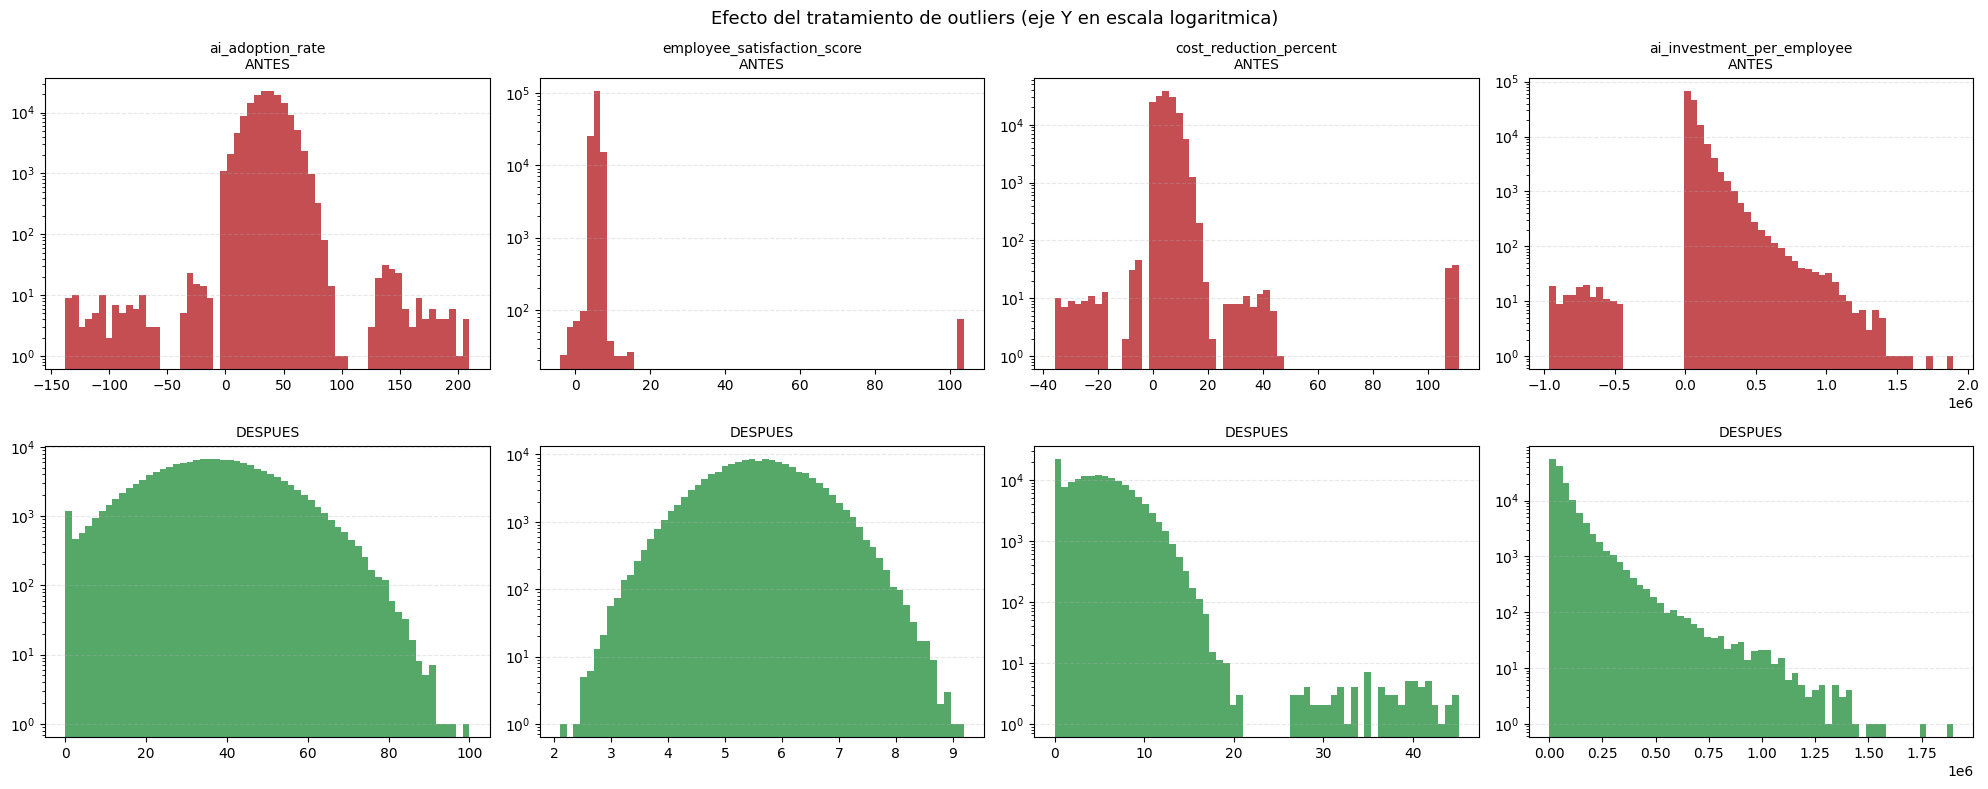

In [ ]:
# 4. Antes y despues, visualmente
variables_grafico = ["ai_adoption_rate", "employee_satisfaction_score",
                     "cost_reduction_percent", "ai_investment_per_employee"]
fig, axes = plt.subplots(2, 4, figsize=(20, 8))

for j, col in enumerate(variables_grafico):
    axes[0, j].hist(df_antes[col].dropna(), bins=60, color="#c44e52", edgecolor="none")
    axes[0, j].set_title(f"{col}\nANTES", fontsize=10)
    axes[1, j].hist(df[col].dropna(), bins=60, color="#55a868", edgecolor="none")
    axes[1, j].set_title("DESPUES", fontsize=10)
    for i in (0, 1):
        axes[i, j].set_yscale("log")
        axes[i, j].grid(axis="y", alpha=0.3, ls="--")

plt.suptitle("Efecto del tratamiento de outliers (eje Y en escala logaritmica)", fontsize=13)
plt.tight_layout()
plt.show()

**Cómo quedó la sección**

Convertimos a `NaN` **2.106 valores**, que es el 0,18% de las celdas de las ocho columnas tratadas, repartidos en 2.090 filas y 1.888 empresas. No eliminamos ninguna fila.

Los cuatro criterios y para qué sirvió cada uno:

| Criterio | Qué encontró | Qué hicimos con él |
|---|---|---|
| Tukey (IQR) | 162.495 valores, hasta el 19% en las variables asimétricas | No lo usamos para cortar: marca la cola larga legítima de los conteos |
| Dominio | 1.129 valores imposibles según el significado de la variable | El más claro, no admite discusión |
| Discontinuidad | Grupos aislados por un hueco, ~150 por cola | Necesario donde no hay límite teórico; lo pudimos validar contra el dominio en `cost_reduction_percent` |
| Consistencia intra-empresa | 300 trimestres que contradicen a su propia empresa | El más fuerte: no usa umbrales ni supuestos |

En las variables donde el problema era la contaminación el efecto se nota: la curtosis de `cost_reduction_percent`, que en el P1 nos había dado 180, baja a 3,2; la de `employee_satisfaction_score` cae de 1.479 a casi 0; y `productivity_change_percent` pasa de 43,7 a 3,1.

Hay un caso que conviene aclarar: **`ai_investment_per_employee` quedó incluso más asimétrica que antes** (de 3,34 a 4,49, con curtosis todavía en 34). No es que el tratamiento haya fallado, es que solo tocamos sus 152 valores negativos. Su cola alta llega a 1,9 millones de dólares por empleado, pero es continua —1.017 valores por encima de 500.000, sin ningún grupo aislado— porque la variable es un cociente entre presupuesto y cantidad de empleados: una empresa de 12 personas con presupuesto alto da legítimamente un número enorme. Esa asimetría es real y no se arregla recortando sino normalizando, cosa que vemos en la § 5.

Las variables de conteo (`jobs_displaced`, `jobs_created`, `reskilled_employees`) no las tocamos: su asimetría es del fenómeno, no un defecto de los datos, y también las normalizamos en la § 5.

**Lo más difícil de decidir** fue el corte de la cola alta en `productivity_change_percent`, `revenue_growth_percent` y `ai_training_hours`, porque ahí no hay ni límite teórico ni acumulación en el tope. El único fundamento es el hueco. Decidimos corregirlos porque el criterio funcionó bien donde lo pudimos verificar, pero es el punto del práctico donde otra decisión también hubiera sido defendible.

<a id="4"></a>

---

# 4. Variables categóricas

> **Consigna**
> Decidí qué hacer con las variables categóricas de cara al modelado: ¿las codificás? ¿las agrupás? ¿las descartás? Justificá cada decisión e implementá al menos una estrategia de encoding.

Antes de codificar conviene mirar qué estamos codificando. Una variable categórica puede ser algo real de la empresa, una etiqueta administrativa de la encuesta, o una versión más gruesa de algo que ya tenemos en otra columna. Codificar todo sin mirar agrega columnas sin agregar información.

Nos hicimos tres preguntas antes de decidir:

1. ¿Describe a la empresa o cambia en cada encuesta?
2. ¿Es redundante con alguna variable numérica que ya tenemos?
3. ¿Aporta algo por encima de otra categórica?

## 4.1 Inventario

In [ ]:
categoricas = [col for col in df.columns
               if df[col].dtype == object or str(df[col].dtype) == "str"]

inventario = pd.DataFrame({
    "categorias":           [df[c].nunique() for c in categoricas],
    "valores_por_empresa":  [df.groupby("company_id")[c].nunique(dropna=True).max() for c in categoricas],
    "nulos":                [int(df[c].isna().sum()) for c in categoricas],
    "categoria_mas_comun":  [f"{df[c].value_counts().index[0]} "
                             f"({df[c].value_counts().iloc[0] / df[c].notna().sum() * 100:.0f}%)"
                             for c in categoricas],
}, index=categoricas).sort_values("categorias")

print(f"Variables categoricas: {len(categoricas)}")
inventario

Variables categoricas: 15


,categorias,valores_por_empresa,nulos,categoria_mas_comun
ai_ethics_committee,2,2,2250,No (59%)
company_size,3,1,0,SME (43%)
data_privacy_level,3,3,2250,High (43%)
country_ai_policy,3,1,0,Moderate (56%)
survey_source,4,4,2250,LinkedIn Poll (25%)
quarter,4,4,0,Q4 (25%)
company_age_group,4,2,0,16-30 years (46%)
ai_adoption_stage,4,4,0,partial (53%)
data_collection_method,4,4,0,Research Compilation (25%)
ai_primary_tool,6,6,2250,ChatGPT (31%)


La columna `valores_por_empresa` ya deja ver el problema. `industry`, `country`, `region` y `company_size` toman un solo valor por empresa, que es lo esperable. Pero `ai_primary_tool` llega a 6 valores distintos dentro de la misma empresa y `data_privacy_level` a 3, o sea todas las categorías posibles.

Una empresa que cambia su herramienta principal de IA seis veces en cuatro años, o que va rotando su nivel de privacidad entre bajo, medio y alto, no está describiendo nada estable. Pero mejor medirlo que suponerlo.

## 4.2 ¿Describe a la empresa o cambia en cada encuesta?

La idea es simple: si una variable con `k` categorías se sorteara al azar en cada uno de los `T` trimestres de una empresa, esperaríamos ver más o menos `k · (1 − ((k−1)/k)^T)` categorías distintas en esa empresa.

Comparamos ese número con el que se observa. Si dan parecido, la variable es indistinguible de un sorteo. Si el observado es bastante menor, hay algo estable que se repite dentro de cada empresa.

In [ ]:
filas = []
for col in ["ai_primary_tool", "ai_use_case", "data_privacy_level", "ai_ethics_committee",
            "ai_adoption_stage", "company_age_group", "survey_source", "data_collection_method"]:
    k = df[col].nunique()
    distintas   = df.groupby("company_id")[col].nunique(dropna=True)
    trimestres  = df.groupby("company_id")[col].apply(lambda s: s.notna().sum())
    esperado    = (k * (1 - ((k - 1) / k) ** trimestres)).mean()
    filas.append({"variable": col, "categorias": k,
                  "distintas_observadas": round(distintas.mean(), 2),
                  "esperado_si_fuera_azar": round(esperado, 2),
                  "ratio": round(distintas.mean() / esperado, 2)})

pd.DataFrame(filas).sort_values("ratio", ascending=False)

,variable,categorias,distintas_observadas,esperado_si_fuera_azar,ratio
3,ai_ethics_committee,2,2.00,2.00,1.00
7,data_collection_method,4,3.94,3.94,1.00
6,survey_source,4,3.94,3.94,1.00
2,data_privacy_level,3,2.89,2.99,0.97
0,ai_primary_tool,6,5.28,5.59,0.95
1,ai_use_case,8,3.95,6.91,0.57
4,ai_adoption_stage,4,2.20,3.94,0.56
5,company_age_group,4,1.28,3.94,0.32


El resultado es bastante claro.

`ai_ethics_committee` (ratio 1,00), `data_privacy_level` (0,97), `ai_primary_tool` (0,95), `survey_source` y `data_collection_method` se comportan **igual que un sorteo**. Casi todas las empresas muestran todas las categorías posibles a lo largo de sus trimestres. No son atributos de la empresa, son valores que se asignaron al azar en cada encuesta.

Esto trae un problema práctico: al agregar a nivel empresa habría que quedarse con un valor, por ejemplo la moda, pero la moda de quince sorteos al azar no significa nada. Codificarlas sería sumar columnas de ruido, y en un clustering como el del P3 eso ensucia las distancias.

En cambio `ai_use_case` (0,57), `ai_adoption_stage` (0,56) y `company_age_group` (0,32) sí muestran estructura, así que las miramos con más detalle.

Como control extra, para `survey_source` y `data_collection_method` chequeamos si al menos las categorías se diferencian en los resultados.

In [ ]:
for col in ["survey_source", "data_collection_method"]:
    t = df.groupby(col)[["ai_adoption_rate", "productivity_change_percent", "num_employees"]].mean()
    print(f"\n{col}:")
    print(t.round(2).to_string())
    print("  amplitud entre categorias:",
          {k: round(t[k].max() - t[k].min(), 2) for k in t.columns})


survey_source:
                           ai_adoption_rate  productivity_change_percent  num_employees
survey_source                                                                          
Internal Corporate Survey             36.42                         9.30        2345.14
LinkedIn Poll                         36.39                         9.31        2314.60
McKinsey Report                       36.46                         9.32        2336.92
WEF Survey                            36.40                         9.23        2363.08
  amplitud entre categorias: {'ai_adoption_rate': np.float64(0.08), 'productivity_change_percent': np.float64(0.09), 'num_employees': np.float64(48.48)}

data_collection_method:
                        ai_adoption_rate  productivity_change_percent  num_employees
data_collection_method                                                              
API Scrape                         36.43                         9.28        2351.57
Online Survey          

Las cuatro fuentes de encuesta dan tasas de adopción de 36,41 a 36,48, y los cuatro métodos de recolección de 36,41 a 36,45. Sobre 150.000 filas, diferencias de cuatro centésimas son básicamente cero.

Son datos de cómo se tomó la encuesta, no de cómo es la empresa. Y aun si hubiera una diferencia real de método, seguiría describiendo el relevamiento y no lo que queremos modelar.

## 4.3 Categóricas que repiten algo que ya tenemos

Otras tres categóricas resultaron ser versiones en tramos de variables numéricas que ya tenemos. Lo chequeamos comparando los rangos.

In [ ]:
print("=== company_size vs. num_employees ===")
print(df.groupby("company_size")["num_employees"].agg(["min", "max", "count"]).to_string())
prediccion = pd.cut(df["num_employees"], [0, 99, 999, np.inf],
                    labels=["Startup", "SME", "Enterprise"])
coincide = (prediccion.astype(str) == df["company_size"].astype(str))
print(f"\n  num_employees predice company_size en {coincide.sum():,} de "
      f"{int(df['company_size'].notna().sum()):,} filas "
      f"({coincide.sum() / df['company_size'].notna().sum() * 100:.2f}%)")

print("\n\n=== ai_adoption_stage vs. ai_adoption_rate ===")
print(df.groupby("ai_adoption_stage")["ai_adoption_rate"]
        .agg(["min", "max", "count"]).round(2).to_string())

print("\n\n=== company_age_group vs. company_age ===")
print(df.groupby("company_age_group")["company_age"].agg(["min", "max", "count"]).to_string())

=== company_size vs. num_employees ===
                 min      max  count
company_size                        
Enterprise    1010.0  19970.0  29448
SME            100.0    999.0  63867
Startup         10.0     99.0  56685

  num_employees predice company_size en 150,000 de 150,000 filas (100.00%)


=== ai_adoption_stage vs. ai_adoption_rate ===
                    min     max  count
ai_adoption_stage                     
full               70.0  100.00   1652
none                0.0    9.99   5106
partial            35.0   69.99  77490
pilot              10.0   34.99  63204


=== company_age_group vs. company_age ===
                    min   max  count
company_age_group                   
0-5 years           1.0   5.0  15372
16-30 years        16.0  30.0  68383
30+ years          31.0  36.0  20253
6-15 years          6.0  15.0  45992


Las tres son discretizaciones exactas, sin ninguna excepción:

| Categórica | Es | Cortes |
|---|---|---|
| `company_size` | `num_employees` en tramos | <100 = Startup, 100–999 = SME, ≥1000 = Enterprise |
| `ai_adoption_stage` | `ai_adoption_rate` en tramos | <10 = none, 10–35 = pilot, 35–70 = partial, ≥70 = full |
| `company_age_group` | `company_age` en tramos | 0–5, 6–15, 16–30, 31+ años |

`num_employees` predice `company_size` en el **100,00%** de las filas, y los cortes de `ai_adoption_stage` caen justo en 10, 35 y 70.

Tener las dos versiones sería duplicar la misma información y encima una de las copias tiene menos resolución: la categórica mete en la misma bolsa a una empresa de 105 empleados y a una de 980. Nos quedamos con las numéricas.

> Igual `ai_adoption_stage` no es inútil: de hecho nos sirve para confirmar que `ai_adoption_rate` está bien armada, porque las etapas ordenan la tasa de menor a mayor sin pisarse. Lo que no aporta es información nueva.

## 4.4 `ai_use_case`: un menú que fija la industria

In [ ]:
tabla_uso = pd.crosstab(df["industry"], df["ai_use_case"], normalize="index") * 100
print("Distribucion de casos de uso dentro de cada industria (%):\n")
print(tabla_uso.round(1).to_string())

casos_por_industria = (tabla_uso > 0).sum(axis=1)
print(f"\nCasos de uso distintos que aparecen en cada industria: "
      f"{casos_por_industria.min()} a {casos_por_industria.max()}")

Distribucion de casos de uso dentro de cada industria (%):

ai_use_case    Customer Support  Fraud Detection  HR Automation  Marketing Automation  Medical Diagnostics  Predictive Maintenance  Software Development  Supply Chain Optimization
industry                                                                                                                                                                           
Agriculture                25.2              0.0           25.0                   0.0                  0.0                    25.1                   0.0                       24.8
Consulting                 25.1              0.0           25.6                  24.1                  0.0                     0.0                  25.2                        0.0
Education                  25.5              0.0           24.0                  25.1                  0.0                     0.0                  25.4                        0.0
Finance                    25.0         

Acá el patrón es bastante evidente: **cada industria tiene exactamente cuatro casos de uso posibles y dentro de esos cuatro la asignación es uniforme al 25%**. Agriculture solo registra Customer Support, HR Automation, Predictive Maintenance y Supply Chain Optimization. Healthcare es la única con Medical Diagnostics, y Finance y Retail las únicas con Fraud Detection.

Eso explica el ratio de 0,57 que nos había dado antes: la estructura que detectamos no era de la empresa sino de su industria. Alguien definió un menú por sector y después sorteó dentro de ese menú.

Así que `ai_use_case` no dice nada de una empresa que `industry` no diga ya. La parte que informa es la industria y el resto es ruido, así que la descartamos.

## 4.5 `country`: 30 categorías que ya están representadas

`country` es distinto. Es un atributo real y constante por empresa, así que no le aplica ninguna de las objeciones anteriores. El problema es otro: codificarla con one-hot serían 30 columnas binarias, cada una casi vacía (los países más chicos tienen 3% de las filas), y en un algoritmo de distancias eso son 30 dimensiones nuevas donde 29 valen cero en cada fila.

Pero no hace falta, porque en la § 1 ya integramos `df3`, que describe a cada país con seis indicadores numéricos: PBI per cápita, penetración de internet, madurez digital, patentes, investigadores y política regulatoria.

Esas seis columnas describen mejor al país que un dummy. Un dummy solo dice "es Japón o no es Japón"; los indicadores dicen en qué se parece Japón a Corea del Sur y en qué se diferencia de Kenia.

Así que dejamos `country` como etiqueta, para poder interpretar los resultados después, pero no la codificamos.

`region` sí la codificamos: son solo 6 categorías, agrupa países de forma interpretable y captura cosas geográficas o culturales que los indicadores económicos no necesariamente reflejan.

## 4.6 Resumen de las decisiones

| Variable | Categorías | Qué encontramos | Qué hicimos |
|---|---|---|---|
| `company_id` | 10.000 | Es el identificador | Lo dejamos como clave |
| `quarter` | 4 | Marca de tiempo | Se pierde al agregar por empresa |
| `survey_source` | 4 | Ratio de azar ≈1, y amplitud de 0,07 entre categorías | Descartar |
| `data_collection_method` | 4 | Ratio de azar ≈1, amplitud de 0,04 | Descartar |
| `ai_ethics_committee` | 2 | Ratio de azar **1,00** | Descartar |
| `data_privacy_level` | 3 | Ratio de azar **0,97** | Descartar |
| `ai_primary_tool` | 6 | Ratio de azar **0,95** | Descartar |
| `ai_use_case` | 8 | Menú fijo por industria, 25% uniforme adentro | Descartar |
| `company_size` | 3 | Se deduce al 100% de `num_employees` | Descartar |
| `company_age_group` | 4 | Tramos exactos de `company_age` | Descartar |
| `ai_adoption_stage` | 4 | Cortes exactos de `ai_adoption_rate` | Descartar |
| `country` | 30 | Ya está representada por los 6 indicadores de `df3` | Dejar como etiqueta |
| **`industry`** | 9 | Real, informativa y no redundante | **One-hot** |
| **`region`** | 6 | Real y con pocas categorías | **One-hot** |
| **`country_ai_policy`** | 3 | Tiene orden: Lenient < Moderate < Strict | **Ordinal** |

Descartamos diez de quince, que es bastante, pero ninguna porque sí: cada una tiene una prueba atrás. La razón de fondo es que agregar columnas sin información no sale gratis. En un algoritmo de distancias, cada dimensión de ruido acerca artificialmente empresas que en realidad son distintas, y el efecto se va sumando.

**Sobre agrupar categorías**, que también lo pregunta la consigna: acá no hace falta. Ninguna de las tres que conservamos tiene categorías raras. La industria menos frecuente es Consulting con 8,2% de las filas y la región más chica es North America con 6,5%. Agrupar tendría sentido si hubiera categorías con muy pocos casos, y no es el caso.

## 4.7 Implementación

Usamos dos estrategias según el tipo de variable.

**One-hot** para `industry` y `region`, que son nominales: sus categorías no tienen un orden. Si les pusiéramos números (Technology = 1, Finance = 2...) el modelo entendería que Finance está más lejos de Technology que de Healthcare, y eso no significa nada.

No usamos `drop_first`. Sacar una categoría de referencia hace falta en regresión lineal, pero el P3 es no supervisado y ahí conviene tener todas las categorías representadas por igual para calcular distancias. Si en el P4 usamos un modelo lineal lo revisamos.

**Ordinal** para `country_ai_policy`, porque ahí sí hay un orden: Lenient es menos restrictiva que Moderate y ésta menos que Strict. Codificarla como 0, 1, 2 conserva ese orden en una sola columna en vez de gastar tres.

In [ ]:
# --- Estrategia 1: one-hot para las nominales ---
nominales = ["industry", "region"]
dummies = pd.get_dummies(df[nominales], prefix=nominales, dtype=int)

# --- Estrategia 2: codificacion ordinal para la unica ordinal que se conserva ---
orden_politica = {"Lenient": 0, "Moderate": 1, "Strict": 2}
df["country_ai_policy_ord"] = df["country_ai_policy"].map(orden_politica)

df = pd.concat([df, dummies], axis=1)

print(f"Columnas creadas por one-hot: {dummies.shape[1]}")
print(f"  {list(dummies.columns)}\n")
print("Codificacion ordinal de country_ai_policy:")
print(df.groupby("country_ai_policy")["country_ai_policy_ord"].first().sort_values().to_string())
print(f"\nColumnas del dataset: {df.shape[1]}")

Columnas creadas por one-hot: 15
  ['industry_Agriculture', 'industry_Consulting', 'industry_Education', 'industry_Finance', 'industry_Healthcare', 'industry_Logistics', 'industry_Manufacturing', 'industry_Retail', 'industry_Technology', 'region_Africa', 'region_Asia', 'region_Europe', 'region_North America', 'region_Oceania', 'region_South America']

Codificacion ordinal de country_ai_policy:


country_ai_policy
Lenient     0
Moderate    1
Strict      2

Columnas del dataset: 72


In [ ]:
# Verificacion: el one-hot es consistente (una sola categoria activa por fila)
suma_industry = dummies[[c for c in dummies.columns if c.startswith("industry_")]].sum(axis=1)
suma_region   = dummies[[c for c in dummies.columns if c.startswith("region_")]].sum(axis=1)

print(f"Filas con exactamente una industria activa: {(suma_industry == 1).sum():,} de {len(df):,}")
print(f"Filas con exactamente una region activa   : {(suma_region == 1).sum():,} de {len(df):,}")
print(f"Nulos en country_ai_policy_ord            : {int(df['country_ai_policy_ord'].isna().sum())}")

print("\nMuestra del resultado:")
df[["company_id", "industry", "industry_Technology", "industry_Finance",
    "region", "region_Europe", "country_ai_policy", "country_ai_policy_ord"]].head(4)

Filas con exactamente una industria activa: 150,000 de 150,000
Filas con exactamente una region activa   : 150,000 de 150,000
Nulos en country_ai_policy_ord            : 0

Muestra del resultado:


,company_id,industry,industry_Technology,industry_Finance,region,region_Europe,country_ai_policy,country_ai_policy_ord
0,COMP-00001,Education,0,0,Europe,1,Moderate,1
1,COMP-00001,Education,0,0,Europe,1,Moderate,1
2,COMP-00001,Education,0,0,Europe,1,Moderate,1
3,COMP-00001,Education,0,0,Europe,1,Moderate,1


**Cómo quedó la sección**

De las quince variables categóricas, tres se codifican, una queda como etiqueta, una es la clave de empresa y diez las descartamos.

Lo más interesante de la sección no fue el encoding en sí, que es bastante mecánico, sino lo que apareció al mirar las variables antes de codificarlas: **cinco de ellas no describen a la empresa**. `ai_ethics_committee`, `data_privacy_level`, `ai_primary_tool`, `survey_source` y `data_collection_method` se sortean en cada encuesta, con ratios de aleatoriedad entre 0,95 y 1,00. Si las hubiéramos codificado sin mirar, el P3 habría trabajado con diecinueve columnas binarias de ruido mezcladas entre las variables reales.

Otras tres (`company_size`, `company_age_group` y `ai_adoption_stage`) resultaron ser recortes exactos de variables numéricas que ya teníamos, y `ai_use_case` un menú que depende de la industria.

Al final el encoding agrega 15 columnas binarias (9 de industria y 6 de región) más una ordinal, y el contexto de cada país entra por los seis indicadores de `df3` en lugar de treinta columnas casi vacías.

<a id="5"></a>

---

# 5. Selección de variables

> **Consigna**
> Seleccioná las variables que van a usar en el Práctico 3, conectando esta decisión con las preguntas de investigación que plantearon en el P1. Justificá tanto las inclusiones como las exclusiones. Prestá especial atención a aquellas variables cuyo significado o forma de construcción no resulte del todo evidente: discutí qué riesgos implica incluirlas sin entenderlas del todo. Un análisis de correlaciones entre variables candidatas puede ser un buen punto de partida para detectar redundancias.

## 5.1 Qué queremos poder responder

La selección no se hace en el aire, se hace pensando en qué queremos responder. En el P1 dejamos planteadas dos hipótesis, y el P3 va a buscar perfiles de empresas sin una variable objetivo definida.

**Hipótesis 1 — retorno económico de la inversión en IA.** Necesitamos las variables de inversión (`ai_budget_percentage`), las de resultado (`productivity_change_percent`, `cost_reduction_percent`, `revenue_growth_percent`) y controles como industria, país y tamaño, para poder descartar que la relación sea un efecto de composición.

**Hipótesis 2 — efecto neto de la IA sobre el empleo.** Necesitamos las variables de impacto laboral, pero el P1 dejó claro que primero hay que normalizarlas por tamaño de empresa. Eso lo hacemos acá.

**Y el objetivo del P3.** Como el clustering mide distancias entre empresas, toda variable que incluyamos pesa en esa distancia. Eso cambia bastante el criterio respecto de un modelo supervisado: acá la redundancia hace daño directo. Si cinco variables miden lo mismo, ese aspecto pesa cinco veces y termina dominando los grupos.

## 5.2 Normalizar el impacto laboral (pendiente del P1)

El P1 ya había anticipado el problema: `jobs_displaced`, `jobs_created` y `reskilled_employees` son conteos absolutos. Una empresa de 15.000 empleados que desplaza 200 puestos y una de 300 que desplaza 30 no son comparables en números absolutos, aunque la segunda la esté pasando bastante peor.

Primero medimos cuánto de esas variables es simplemente tamaño de empresa.

In [ ]:
for absoluta in ["jobs_displaced", "jobs_created", "reskilled_employees"]:
    r = df[[absoluta, "num_employees"]].corr().iloc[0, 1]
    print(f"  correlacion {absoluta:22s} con num_employees: {r:+.3f}")

  correlacion jobs_displaced         con num_employees: +0.896
  correlacion jobs_created           con num_employees: +0.933
  correlacion reskilled_employees    con num_employees: +0.902


Con correlaciones de **+0,90 a +0,93**, esas tres variables están midiendo el tamaño de la empresa más que el impacto de la IA. Si hiciéramos el clustering con ellas nos separaría empresas grandes de chicas, que es algo que ya sabemos y no es lo que queremos averiguar.

La solución que propuso el P1 es dividir por la cantidad de empleados y convertir los conteos en tasas: qué porcentaje de la plantilla fue desplazado, creado o reentrenado. Así las empresas se vuelven comparables sin importar el tamaño, y de paso se resuelve la objeción que habíamos anotado sobre las comparaciones entre países, donde las diferencias podían venir del tamaño promedio de empresa de cada país.

In [ ]:
# Conteos absolutos -> tasas sobre la plantilla (en %)
df["tasa_desplazamiento"]  = df["jobs_displaced"]      / df["num_employees"] * 100
df["tasa_creacion"]        = df["jobs_created"]        / df["num_employees"] * 100
df["tasa_reentrenamiento"] = df["reskilled_employees"] / df["num_employees"] * 100
df["saldo_neto_empleo"]    = df["tasa_creacion"] - df["tasa_desplazamiento"]

comparacion = pd.DataFrame([
    {"absoluta": a, "corr_con_tamanio_antes": df[[a, "num_employees"]].corr().iloc[0, 1],
     "normalizada": n, "corr_con_tamanio_despues": df[[n, "num_employees"]].corr().iloc[0, 1],
     "asimetria_antes": df[a].skew(), "asimetria_despues": df[n].skew()}
    for a, n in [("jobs_displaced", "tasa_desplazamiento"),
                 ("jobs_created", "tasa_creacion"),
                 ("reskilled_employees", "tasa_reentrenamiento")]
])
comparacion.round(3)

,absoluta,corr_con_tamanio_antes,normalizada,corr_con_tamanio_despues,asimetria_antes,asimetria_despues
0,jobs_displaced,0.896,tasa_desplazamiento,0.107,3.032,0.095
1,jobs_created,0.933,tasa_creacion,0.168,2.787,-0.021
2,reskilled_employees,0.902,tasa_reentrenamiento,0.174,2.986,0.156


La normalización hizo las dos cosas que buscábamos.

Por un lado, desacopló del tamaño: la correlación con `num_employees` cae de ~+0,91 a valores entre +0,11 y +0,17. Lo que queda es una relación real (las empresas grandes automatizan algo más) y no un efecto de escala.

Por otro, corrigió la asimetría. En el P1 habíamos visto que estas variables eran muy asimétricas a la derecha, con moda en 0 y colas de miles. Ahora la asimetría pasa de ~3,0 a casi nada (entre −0,02 y +0,16). Esto importa porque el clustering es sensible a las colas largas: sin normalizar, un puñado de empresas gigantes dominaría la formación de los grupos.

También agregamos `saldo_neto_empleo` (creación menos desplazamiento), que responde bastante directo a la pregunta central del proyecto: si la IA en cada empresa crea o destruye empleo neto.

## 5.3 Agregación a nivel empresa

Acá aplicamos la decisión del P1: el análisis se hace a nivel empresa promediando trimestres, porque las variables económicas tenían entre 70% y 88% de su varianza dentro de cada empresa, o sea que era más fluctuación de corto plazo que diferencias estructurales.

Lo hacemos recién ahora y no antes porque, como decíamos en la § 1.6, si promediábamos primero los valores raros habrían quedado escondidos adentro del promedio de cada empresa y no los podríamos haber detectado.

In [ ]:
numericas_panel = [col for col in df.select_dtypes(include=np.number).columns
                   if col not in ("response_id", "survey_year", "company_founding_year")]

agregacion = {col: (col, "mean") for col in numericas_panel}
agregacion.update({
    "industry":          ("industry", "first"),      # constantes por empresa (verificado en la 2.4)
    "country":           ("country", "first"),
    "region":            ("region", "first"),
    "company_size":      ("company_size", "first"),
    "country_ai_policy": ("country_ai_policy", "first"),
    "n_trimestres":      ("response_id", "size"),
})

empresas = df.groupby("company_id").agg(**agregacion).reset_index()

print(f"Panel     : {len(df):,} filas (empresa x trimestre)")
print(f"Empresas  : {len(empresas):,} filas x {empresas.shape[1]} columnas")
print(f"Trimestres por empresa: minimo {empresas['n_trimestres'].min()}, "
      f"mediana {empresas['n_trimestres'].median():.0f}, maximo {empresas['n_trimestres'].max()}")
print(f"\nValores faltantes tras la agregacion: {int(empresas.isna().sum().sum())}")

Panel     : 150,000 filas (empresa x trimestre)
Empresas  : 10,000 filas x 65 columnas
Trimestres por empresa: minimo 10, mediana 15, maximo 16

Valores faltantes tras la agregacion: 0


Los faltantes desaparecieron del todo, que es justo lo que esperábamos desde las secciones 2 y 3: los `NaN` de cada trimestre los omite el promedio, y ninguna empresa se quedaba sin valores. **No inventamos ningún dato en todo el proceso.**

## 5.4 Cuánta información distinta hay realmente

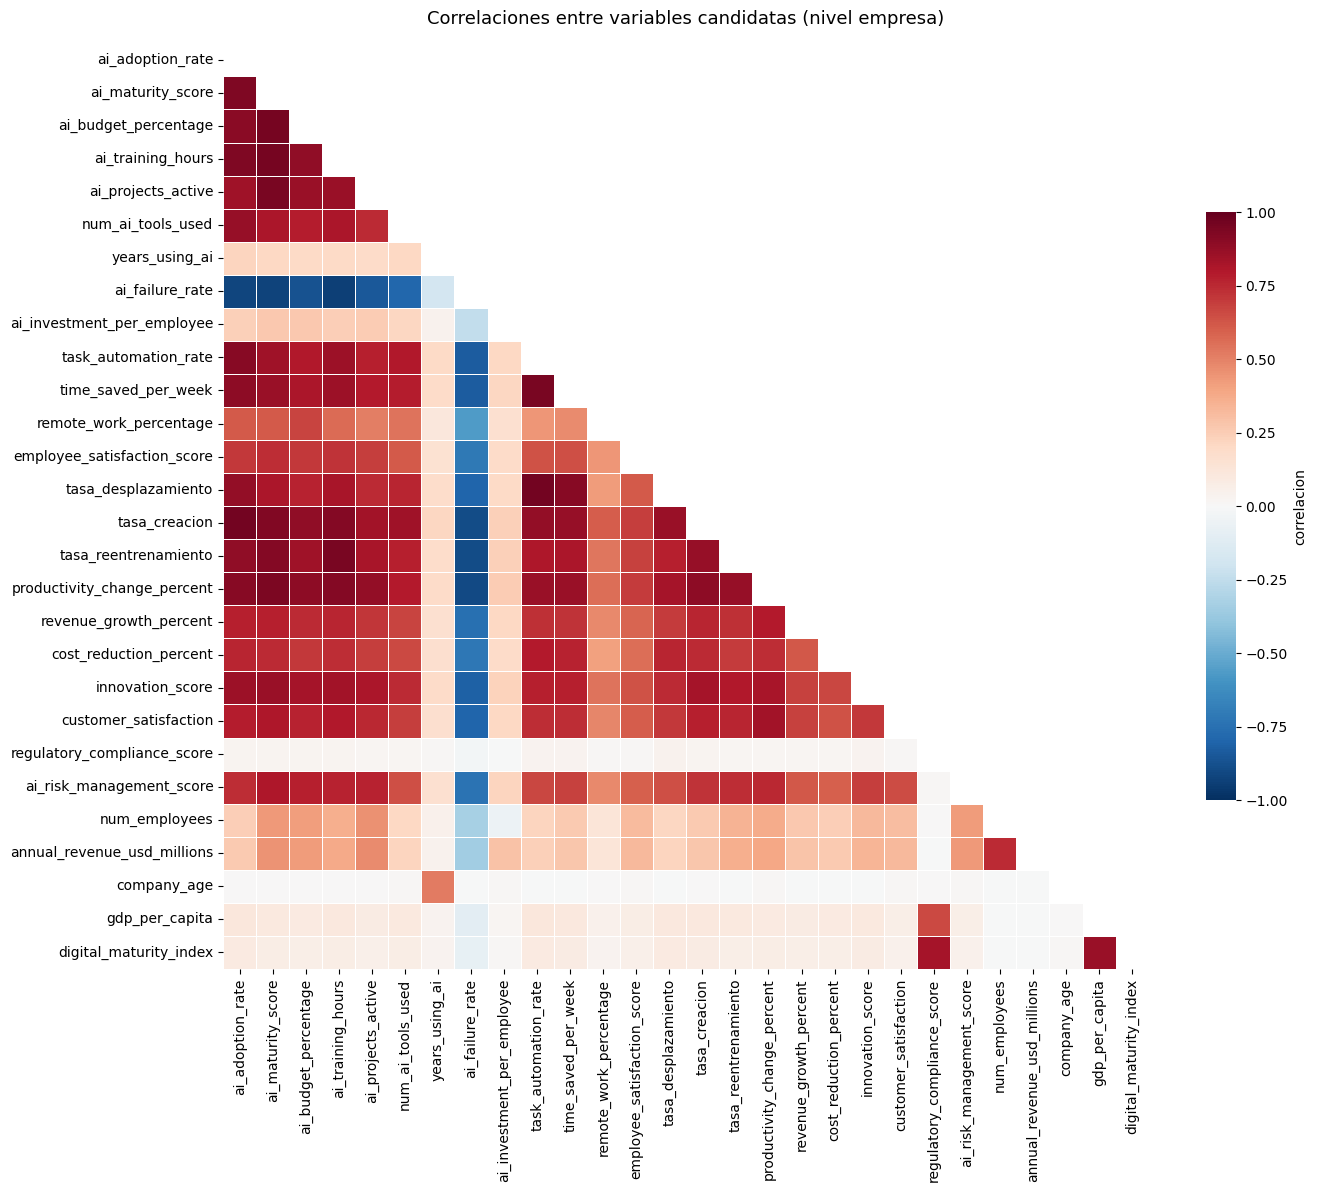

In [ ]:
candidatas = [
    # adopcion de IA
    "ai_adoption_rate", "ai_maturity_score", "ai_budget_percentage", "ai_training_hours",
    "ai_projects_active", "num_ai_tools_used", "years_using_ai", "ai_failure_rate",
    "ai_investment_per_employee",
    # impacto en personas
    "task_automation_rate", "time_saved_per_week", "remote_work_percentage",
    "employee_satisfaction_score",
    # impacto laboral (normalizado)
    "tasa_desplazamiento", "tasa_creacion", "tasa_reentrenamiento",
    # resultados de negocio
    "productivity_change_percent", "revenue_growth_percent", "cost_reduction_percent",
    "innovation_score", "customer_satisfaction",
    # gobernanza
    "regulatory_compliance_score", "ai_risk_management_score",
    # estructura y contexto
    "num_employees", "annual_revenue_usd_millions", "company_age",
    "gdp_per_capita", "digital_maturity_index",
]

C = empresas[candidatas].corr()

fig, ax = plt.subplots(figsize=(14, 12))
mascara = np.triu(np.ones_like(C, dtype=bool))
sns.heatmap(C, mask=mascara, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.4, cbar_kws={"shrink": 0.6, "label": "correlacion"}, ax=ax)
ax.set_title("Correlaciones entre variables candidatas (nivel empresa)", fontsize=13, pad=14)
plt.tight_layout()
plt.show()

In [ ]:
# Pares con correlacion muy alta: candidatos a redundancia
pares = [(candidatas[i], candidatas[j], C.iloc[i, j])
         for i in range(len(candidatas)) for j in range(i + 1, len(candidatas))
         if abs(C.iloc[i, j]) > 0.90]

print(f"Pares de variables con |correlacion| > 0,90: {len(pares)}\n")
for a, b, r in sorted(pares, key=lambda x: -abs(x[2]))[:15]:
    print(f"  {r:+.3f}   {a:30s} <-> {b}")

Pares de variables con |correlacion| > 0,90: 21

  +0.968   ai_adoption_rate               <-> tasa_creacion
  +0.961   task_automation_rate           <-> tasa_desplazamiento
  +0.960   ai_maturity_score              <-> ai_budget_percentage
  +0.959   ai_maturity_score              <-> ai_training_hours
  +0.951   ai_training_hours              <-> tasa_reentrenamiento
  +0.949   ai_maturity_score              <-> ai_projects_active
  +0.947   task_automation_rate           <-> time_saved_per_week
  -0.940   ai_training_hours              <-> ai_failure_rate
  +0.940   ai_maturity_score              <-> productivity_change_percent
  +0.936   ai_adoption_rate               <-> ai_maturity_score
  +0.935   ai_adoption_rate               <-> ai_training_hours
  -0.927   ai_maturity_score              <-> ai_failure_rate
  +0.923   ai_maturity_score              <-> tasa_creacion
  +0.917   ai_training_hours              <-> tasa_creacion
  -0.917   ai_adoption_rate               <-> ai_f

El dataset está **muy correlacionado**, y eso condiciona toda la selección. Las variables se agrupan en bloques donde casi todo mide lo mismo:

- **Adopción de IA.** `ai_maturity_score` correlaciona por encima de 0,93 con `ai_adoption_rate`, `ai_budget_percentage`, `ai_training_hours` y `ai_projects_active`, y −0,93 con `ai_failure_rate`. Son nueve variables describiendo básicamente una sola cosa: cuánta IA usa la empresa.
- **Impacto laboral.** Aun normalizadas, `tasa_desplazamiento` y `tasa_creacion` correlacionan +0,86, y `task_automation_rate` da +0,96 con `tasa_desplazamiento`.
- **Contexto del país.** `gdp_per_capita`, `digital_maturity_index`, `internet_penetration` y `ai_researchers_per_million` correlacionan entre sí por encima de 0,83: son cuatro formas de decir "país desarrollado".

Para el clustering esto es un problema concreto. Si nueve variables miden la adopción de IA y dos miden el contexto del país, la adopción va a pesar nueve veces más en la distancia entre empresas, y los grupos que salgan van a reflejar esa decisión nuestra antes que la estructura real de los datos.

Así que la idea es quedarnos con un representante de cada bloque en vez de meter todo.

## 5.5 Variables que no sabemos bien cómo están armadas

La consigna pide prestar atención especial a las variables cuyo significado o forma de construcción no queda claro. Hay cinco así, y vale la pena investigarlas antes de decidir, porque incluir una variable que no entendemos es aceptar que el modelo tome decisiones que después no vamos a poder explicar.

Empezamos por la más rara: `ai_maturity_score` es un índice entre 0 y 0,90 y no hay nada que explique cómo se calcula. Probamos si se puede reconstruir con las demás variables de adopción.

In [ ]:
predictoras = ["ai_adoption_rate", "ai_budget_percentage", "ai_training_hours",
               "ai_projects_active", "num_ai_tools_used", "years_using_ai", "ai_failure_rate"]

def r2_lineal(objetivo, predictoras, datos):
    sub = datos.dropna(subset=predictoras + [objetivo])
    X = np.column_stack([np.ones(len(sub))] + [sub[c].values for c in predictoras])
    y = sub[objetivo].values
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    r2 = 1 - ((y - X @ beta) ** 2).sum() / ((y - y.mean()) ** 2).sum()
    return r2, dict(zip(predictoras, beta[1:]))

# Se calcula sobre el panel (df) y no sobre los promedios por empresa: si la relacion es una
# identidad, tiene que verificarse en cada encuesta, que es donde el dato fue generado.
r2, coefs = r2_lineal("ai_maturity_score", predictoras, df)
print("ai_maturity_score reconstruida a partir de las demas variables de adopcion:")
print(f"  R2 = {r2:.6f}\n")
for var, coef in coefs.items():
    if abs(coef) > 1e-3:
        print(f"    {var:24s} coeficiente {coef:+.6f}   =  1/{1/coef:,.0f}")

print("\nY los otros indices sin documentacion:")
for objetivo in ["innovation_score", "ai_risk_management_score",
                 "regulatory_compliance_score", "customer_satisfaction"]:
    r2_i, _ = r2_lineal(objetivo, predictoras, df)
    print(f"  {objetivo:30s} R2 = {r2_i:.4f}")

ai_maturity_score reconstruida a partir de las demas variables de adopcion:
  R2 = 0.999995

    ai_budget_percentage     coeficiente +0.013333   =  1/75
    ai_training_hours        coeficiente +0.004166   =  1/240
    ai_projects_active       coeficiente +0.016667   =  1/60

Y los otros indices sin documentacion:


  innovation_score               R2 = 0.2959
  ai_risk_management_score       R2 = 0.1988


  regulatory_compliance_score    R2 = 0.0002


  customer_satisfaction          R2 = 0.2376


El R² da **0,999995**, así que no es una correlación alta: es directamente la misma variable. `ai_maturity_score` se arma como

$$\text{ai\_maturity\_score} = \frac{\text{ai\_budget\_percentage}}{75} + \frac{\text{ai\_training\_hours}}{240} + \frac{\text{ai\_projects\_active}}{60}$$

Los coeficientes son fracciones limpias, y se entiende mirando los máximos de cada componente: el presupuesto llega a 25 (25/75 = 1/3), las horas de capacitación a 80 (80/240 = 1/3) y los proyectos a 20 (20/60 = 1/3). O sea que es el promedio de tres variables escaladas a su máximo, un índice armado, no una medición aparte.

Si la incluyéramos junto con sus tres componentes estaríamos contando esa información dos veces, y en un algoritmo de distancias eso duplica el peso de ese aspecto porque sí.

**Los otros cuatro índices sí son independientes**, y eso también sirve: `innovation_score` (R² = 0,30), `ai_risk_management_score` (0,20), `customer_satisfaction` (0,24) y sobre todo `regulatory_compliance_score` (**0,0002**) no se derivan de las variables de adopción. La última es prácticamente independiente de todo el bloque de IA, así que aporta una dimensión que ninguna otra variable cubre.

Falta ver `ai_investment_per_employee`, que el P1 ya había marcado como problemática por sus valores negativos.

> **Un detalle.** Este cálculo lo hacemos sobre el panel y no sobre los promedios por empresa. Si lo corremos sobre `empresas` el R² baja a 0,9995, porque el tratamiento de outliers de la § 3 dejó en `NaN` algún componente en 4.770 filas que igual conservan su `ai_maturity_score`. Al promediar, el índice usa trimestres que sus componentes ya no tienen. Sirve para acordarse de que una relación exacta puede dejar de parecerlo después de agregar.

In [ ]:
sub = df.dropna(subset=["ai_investment_per_employee", "ai_budget_percentage",
                        "annual_revenue_usd_millions", "num_employees"])
formula = (sub["ai_budget_percentage"] / 100 * sub["annual_revenue_usd_millions"] * 1e6
           / sub["num_employees"])

print("ai_investment_per_employee  vs  (ai_budget% x facturacion) / empleados")
print(f"  correlacion                     : {np.corrcoef(sub['ai_investment_per_employee'], formula)[0, 1]:.4f}")
print(f"  ratio observado/formula, mediana: {float((sub['ai_investment_per_employee'] / formula).median()):.4f}")

ai_investment_per_employee  vs  (ai_budget% x facturacion) / empleados
  correlacion                     : 0.9607
  ratio observado/formula, mediana: 1.0000


`ai_investment_per_employee` también es una cuenta: sale de combinar el porcentaje del presupuesto de IA, la facturación anual y la cantidad de empleados, tres variables que ya están en el dataset. El ratio entre el valor observado y la fórmula da 1,0000 en la mediana.

De paso esto explica por qué en la § 3 su cola era tan extrema y por qué no correspondía recortarla: es un cociente donde el denominador puede ser 12 empleados, así que da valores enormes de forma legítima.

**Qué hubiera pasado si no mirábamos esto**

Si hubiéramos incluido `ai_maturity_score` con sus tres componentes y `ai_investment_per_employee` con los suyos, habrían pasado tres cosas:

1. El presupuesto de IA entraría tres veces en la distancia entre empresas: solo, dentro de la madurez y dentro de la inversión por empleado.
2. Al describir los grupos del P3 diríamos "este grupo tiene alta madurez de IA" sin poder explicar qué significa ni en qué se diferencia de "tiene presupuesto alto".
3. Encontrar que la madurez de IA predice la inversión en IA sería un hallazgo vacío, porque es la misma variable.

Lo complicado es que ninguna de esas cosas da error. El código corre, los gráficos salen y los grupos se forman igual. El problema es que las conclusiones no significan lo que uno cree.

## 5.6 Con qué nos quedamos

**Con qué nos quedamos** — 25 variables más las 9 columnas de industria

| Bloque | Variables | Por qué |
|---|---|---|
| **Adopción de IA** | `ai_adoption_rate`, `ai_budget_percentage`, `ai_projects_active`, `ai_training_hours`, `years_using_ai`, `num_ai_tools_used` | Las tres primeras son los componentes reales de la madurez y las otras suman antigüedad y variedad de uso. Van para la Hipótesis 1 y son el núcleo del perfil de adopción |
| **Gobernanza y riesgo** | `ai_failure_rate`, `regulatory_compliance_score`, `ai_risk_management_score` | `regulatory_compliance_score` es casi independiente del resto (R² = 0,0002), así que aporta algo que nada más cubre |
| **Impacto en personas** | `task_automation_rate`, `time_saved_per_week`, `remote_work_percentage`, `employee_satisfaction_score` | En el P1 vimos que pesa más el tipo de tarea automatizada que el volumen |
| **Impacto laboral** | `tasa_desplazamiento`, `tasa_creacion`, `tasa_reentrenamiento`, `saldo_neto_empleo` | Hipótesis 2, ya normalizadas por plantilla |
| **Resultados de negocio** | `productivity_change_percent`, `revenue_growth_percent`, `cost_reduction_percent`, `innovation_score` | Hipótesis 1: los indicadores de retorno que analizamos en el P1 |
| **Estructura** | `num_employees`, `company_age` | Controles para descartar efectos de composición |
| **Contexto del país** | `gdp_per_capita`, `digital_maturity_index` | Dos representantes del bloque de país, que correlacionan >0,83 entre sí |
| **Industria** | 9 columnas one-hot | Control sectorial (§ 4) |

**Qué dejamos afuera y por qué**

| Excluida | Motivo | Sección |
|---|---|---|
| Las 7 columnas `avg_*` de `df2` | Son `df1` promediado por industria, e `industry` ya tiene esa información | § 1.5 |
| `jobs_displaced`, `jobs_created`, `reskilled_employees` | Conteos absolutos que correlacionan +0,90 a +0,93 con el tamaño; usamos sus tasas | § 5.2 |
| `ai_maturity_score` | Es una combinación exacta de presupuesto, capacitación y proyectos (R² = 0,999995) | § 5.5 |
| `ai_investment_per_employee` | Sale de presupuesto × facturación / empleados | § 5.5 |
| `annual_revenue_usd_millions` | Correlaciona +0,75 con `num_employees`; dejamos un solo indicador de tamaño | § 5.4 |
| `customer_satisfaction` | Correlaciona +0,84 con `productivity_change_percent`, que responde más directo a las hipótesis | § 5.4 |
| `internet_penetration`, `ai_researchers_per_million`, `ai_patent_filings_2024` | Mismo bloque de contexto del país, con correlaciones internas >0,83 | § 5.4 |
| 10 variables categóricas | Ruido por trimestre o redundancia con variables numéricas | § 4 |
| `country`, `company_size`, `region` | Las dejamos en el dataset como etiquetas para interpretar los grupos, pero fuera del modelado | § 4.5 |

**Una aclaración.** Dentro del bloque de adopción las correlaciones siguen siendo altas incluso después de la poda: `ai_adoption_rate` y `tasa_creacion` correlacionan +0,97. Bajarlas más implicaría decidir cuál de las dos importa, y eso depende de qué agrupamiento busquemos. La otra opción sería aplicar algo como PCA sobre el bloque, pero eso ya es del P3, donde se puede evaluar si mejora o no. Lo que dejamos acá es un conjunto sin redundancias exactas ni variables derivadas, que es lo mínimo para poder ir por cualquiera de esos caminos.

In [ ]:
variables_p3 = {
    "adopcion":   ["ai_adoption_rate", "ai_budget_percentage", "ai_projects_active",
                   "ai_training_hours", "years_using_ai", "num_ai_tools_used"],
    "gobernanza": ["ai_failure_rate", "regulatory_compliance_score", "ai_risk_management_score"],
    "personas":   ["task_automation_rate", "time_saved_per_week", "remote_work_percentage",
                   "employee_satisfaction_score"],
    "empleo":     ["tasa_desplazamiento", "tasa_creacion", "tasa_reentrenamiento", "saldo_neto_empleo"],
    "negocio":    ["productivity_change_percent", "revenue_growth_percent",
                   "cost_reduction_percent", "innovation_score"],
    "estructura": ["num_employees", "company_age"],
    "pais":       ["gdp_per_capita", "digital_maturity_index"],
}
seleccionadas = [v for bloque in variables_p3.values() for v in bloque]
columnas_industria = [c for c in empresas.columns if c.startswith("industry_")]
etiquetas = ["company_id", "industry", "country", "region", "company_size", "n_trimestres"]

print(f"Variables seleccionadas para el P3: {len(seleccionadas)} + {len(columnas_industria)} de industria\n")
for bloque, variables in variables_p3.items():
    print(f"  {bloque:11s} ({len(variables)}): {', '.join(variables)}")

# Correlacion maxima que queda dentro del conjunto elegido
C_sel = empresas[seleccionadas].corr().abs().to_numpy(copy=True)
np.fill_diagonal(C_sel, 0)
i, j = np.unravel_index(np.argmax(C_sel), C_sel.shape)
print(f"\nCorrelacion mas alta que queda: {C_sel[i, j]:.3f} "
      f"({seleccionadas[i]} <-> {seleccionadas[j]})")

Variables seleccionadas para el P3: 25 + 9 de industria

  adopcion    (6): ai_adoption_rate, ai_budget_percentage, ai_projects_active, ai_training_hours, years_using_ai, num_ai_tools_used
  gobernanza  (3): ai_failure_rate, regulatory_compliance_score, ai_risk_management_score
  personas    (4): task_automation_rate, time_saved_per_week, remote_work_percentage, employee_satisfaction_score
  empleo      (4): tasa_desplazamiento, tasa_creacion, tasa_reentrenamiento, saldo_neto_empleo
  negocio     (4): productivity_change_percent, revenue_growth_percent, cost_reduction_percent, innovation_score
  estructura  (2): num_employees, company_age
  pais        (2): gdp_per_capita, digital_maturity_index

Correlacion mas alta que queda: 0.968 (ai_adoption_rate <-> tasa_creacion)


## 5.7 El dataset para el Práctico 3

In [ ]:
columnas_finales = etiquetas + seleccionadas + columnas_industria + ["country_ai_policy_ord"]
empresas_final = empresas[columnas_finales].copy()

print(f"Dataset final: {empresas_final.shape[0]:,} empresas x {empresas_final.shape[1]} columnas")
print(f"  etiquetas descriptivas : {len(etiquetas)}")
print(f"  variables de modelado  : {len(seleccionadas) + len(columnas_industria) + 1}")
print(f"  valores faltantes      : {int(empresas_final.isna().sum().sum())}")
empresas_final.head(3)

Dataset final: 10,000 empresas x 41 columnas
  etiquetas descriptivas : 6
  variables de modelado  : 35
  valores faltantes      : 0


,company_id,industry,country,region,company_size,n_trimestres,ai_adoption_rate,ai_budget_percentage,ai_projects_active,ai_training_hours,...,industry_Agriculture,industry_Consulting,industry_Education,industry_Finance,industry_Healthcare,industry_Logistics,industry_Manufacturing,industry_Retail,industry_Technology,country_ai_policy_ord
0,COMP-00001,Education,Italy,Europe,Startup,16,37.374667,8.659375,5.000000,27.312500,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,COMP-00002,Finance,UK,Europe,Startup,15,49.020667,10.002000,8.200000,33.956667,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,COMP-00003,Education,Germany,Europe,Enterprise,14,39.461429,10.721429,8.214286,30.555000,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0


In [ ]:
import os
os.makedirs("../data/processed", exist_ok=True)
ruta = "../data/processed/empresas.parquet"

try:
    empresas_final.to_parquet(ruta, index=False)
    print(f"Guardado en {ruta}")
except ImportError:
    ruta = "../data/processed/empresas.csv"
    empresas_final.to_csv(ruta, index=False)
    print(f"pyarrow no disponible; guardado como CSV en {ruta}")

print(f"  {empresas_final.shape[0]:,} filas x {empresas_final.shape[1]} columnas")

Guardado en ../data/processed/empresas.parquet
  10,000 filas x 41 columnas


<a id="6"></a>

---

# 6. Conclusiones parciales

> **Consigna**
> Resumí el estado del dataset después de la curación: qué cambió, qué decisiones fueron las más difíciles, y qué quedó listo para el modelado.

## Qué cambió

Arrancamos con tres archivos sueltos, 150.025 encuestas trimestrales y 43 columnas, más una lista de problemas que el P1 había detectado pero no resuelto. Terminamos con un dataset de **10.000 empresas** listo para el P3.

| Etapa | Qué hicimos | Cómo quedó |
|---|---|---|
| **Integración** | `LEFT JOIN` validado desde `df1` | 150.025 × 56, sin perder ni duplicar filas |
| **Faltantes** | Sacamos 25 filas de prueba y reconstruimos 6.747 valores desde el panel | De 40 a 10 variables con faltantes, sin imputar nada |
| **Outliers** | 2.106 valores imposibles pasados a `NaN` | Curtosis de `cost_reduction_percent` de 180 a 3,2, sin borrar filas |
| **Categóricas** | 3 codificadas y 10 descartadas | 15 columnas one-hot + 1 ordinal, sin 19 columnas de ruido |
| **Selección** | Normalizamos el empleo y podamos redundancias | 10.000 × 41, sin faltantes y sin variables derivadas |

Hubo tres cosas que ordenaron todo el trabajo, y ninguna se veía sin ir a buscarla.

**El dataset venía contaminado a propósito.** Y no al azar: 25 filas rotuladas `COMP-FAKE`, alrededor del 1,5% de valores vaciados en 13 variables y unos 150 valores imposibles por cola en 8 variables. Darnos cuenta de eso cambió bastante el trabajo, porque en vez de aplicar recetas de limpieza tuvimos que ir entendiendo cómo se habían generado los datos.

**Varias variables no eran lo que parecían.** `ai_maturity_score` es una combinación exacta de otras tres (R² = 0,999995). `company_size` es `num_employees` en tres tramos, con 100% de coincidencia. `ai_adoption_stage` son cortes de `ai_adoption_rate` en 10, 35 y 70. `ai_use_case` es un menú que fija la industria. Y las siete columnas de `df2` son `df1` promediado por sector.

**Cinco variables categóricas no describen a la empresa.** `ai_ethics_committee`, `data_privacy_level`, `ai_primary_tool`, `survey_source` y `data_collection_method` se sortean en cada encuesta, con ratios de aleatoriedad entre 0,95 y 1,00.

## Lo más difícil de decidir

**No imputar.** Queda medio raro cerrar la sección de faltantes con 22.489 celdas vacías, y rellenar con la media hubiera dejado todo más prolijo. Pero habría metido valores inventados adentro de promedios que ya se calculaban bien sin ellos, corriendo a cada empresa hacia la media general y borrando parte de la variación entre empresas, que es justo lo que el P3 va a buscar. La estructura de panel nos permitió algo mejor: reconstruir lo que se podía y dejar que el promedio se encargue del resto.

**Cortar la cola alta sin un límite teórico.** En `productivity_change_percent`, `revenue_growth_percent` y `ai_training_hours` no hay ninguna regla que diga cuál es el máximo posible. Que la productividad suba 119% es rarísimo, pero no imposible. Corregimos esos 395 valores apoyándonos en el hueco que los separa del resto y en que el mismo criterio había acertado donde lo pudimos verificar. Sigue siendo lo más discutible del práctico.

**Descartar diez de quince categóricas.** Podar tanto puede parecer demasiado, y la tentación de dejarlas "por las dudas" estaba. Pero en un algoritmo de distancias las columnas de ruido no son neutras: acercan artificialmente empresas que son distintas, y el efecto se acumula con cada dimensión que agregás.

## Qué quedó listo y qué no

**Listo:** un dataset a nivel empresa sin faltantes, sin valores imposibles, sin variables derivadas de otras, con el impacto laboral en tasas comparables entre empresas de cualquier tamaño y con las categóricas codificadas. Cada decisión quedó documentada con la evidencia que la respalda.

**Pendiente para el P3:** el escalado de las variables, que conviene hacer dentro del pipeline de modelado y no acá. Y quizás una reducción de dimensionalidad sobre el bloque de adopción, donde las correlaciones siguen altas (`ai_adoption_rate` y `tasa_creacion` dan +0,97) aunque ya no haya redundancias exactas.

**Lo que queda abierto.** En el P1 nos preguntábamos si la relación entre presupuesto de IA y retorno económico se sostiene al controlar por industria, país y tamaño. Ahora tenemos un dataset que permite responderlo. Pero apareció otra pregunta: con tantas variables correlacionadas por encima de 0,9, ¿cuántas dimensiones independientes tiene realmente este dataset? Puede que sean cinco o seis y no las treinta que aparentaba, y eso condiciona qué tan variados pueden llegar a ser los perfiles que encuentre el P3.

Por último, algo que ya decía el README y conviene no olvidar: **son datos sintéticos**. Que la contaminación sea tan regular, que los índices se reconstruyan con fracciones exactas y que varias categóricas sean sorteos uniformes son señales de que estamos analizando un generador y no un fenómeno real. Las técnicas son las mismas que usaríamos con datos reales, pero las conclusiones sobre el impacto de la IA en el empleo hay que seguir tomándolas con la cautela que ya señalábamos en el P1.